In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from category_encoders import BinaryEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [2]:
import os
csv_path = 'data/CVD_cleaned.csv' if os.path.exists('data/CVD_cleaned.csv') else 'CVD_cleaned.csv'
df = pd.read_csv(csv_path)
df

In [3]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poo,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,m,25-29,168,81.65,29.05,No,4,30,8,0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180,69.85,21.48,No,8,15,60,4
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157,61.23,24.69,Yes,4,40,8,4
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183,79.38,23.73,No,3,30,12,0


In [4]:
df.shape

(308854, 19)

In [5]:
#In the given dataset there are total 308854 rows and 19 columns

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  int64  
 12  Weight_(kg)                   308854 non-nul

In [7]:
#12 attributes with object data type
#5 attributes with integer data type
#2 attributes with float data type

In [8]:
df.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.615249,83.588655,28.626211,5.096366,29.835200,15.110441,6.296616
std,10.658026,21.343210,6.522323,8.199763,24.875735,14.926238,8.582954
min,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.850000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000


In [9]:
df.describe(include='O')

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Smoking_History
count,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854
unique,7,5,2,2,2,2,2,4,2,5,13,2
top,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,65-69,No
freq,110395,239371,239381,283883,278860,278976,246953,259141,207783,160186,33434,183590


Identifying Nulls

In [10]:
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

In [11]:
#In our dataset there are no null values.Therefore treatment of null values is not required.

Treating noise in the categorical columns

In [12]:
df['General_Health'].unique()

array(['Poo', 'Very Good', 'Poor', 'Good', 'Fair', 'Excellent', 'poo'],
      dtype=object)

In [13]:
df['General_Health']=df['General_Health'].replace({'poo':'Poor','Poo':'Poor'})

In [14]:
df['Diabetes'].value_counts()

Diabetes
No                                            259141
Yes                                            40171
No, pre-diabetes or borderline diabetes         6896
Yes, but female told only during pregnancy      2646
Name: count, dtype: int64

In [15]:
 df['Diabetes']=df['Diabetes'].replace({'No, pre-diabetes or borderline diabetes':'No','Yes, but female told only during pregnancy':'No'})

In [16]:
 df['Sex'].unique()

array(['Female', 'Male', 'F', 'M', 'm'], dtype=object)

In [17]:
 df['Sex']=df['Sex'].replace({'F':'Female','M':'Male','m':'Male'})

EDA

1.Univariate Aanalysis

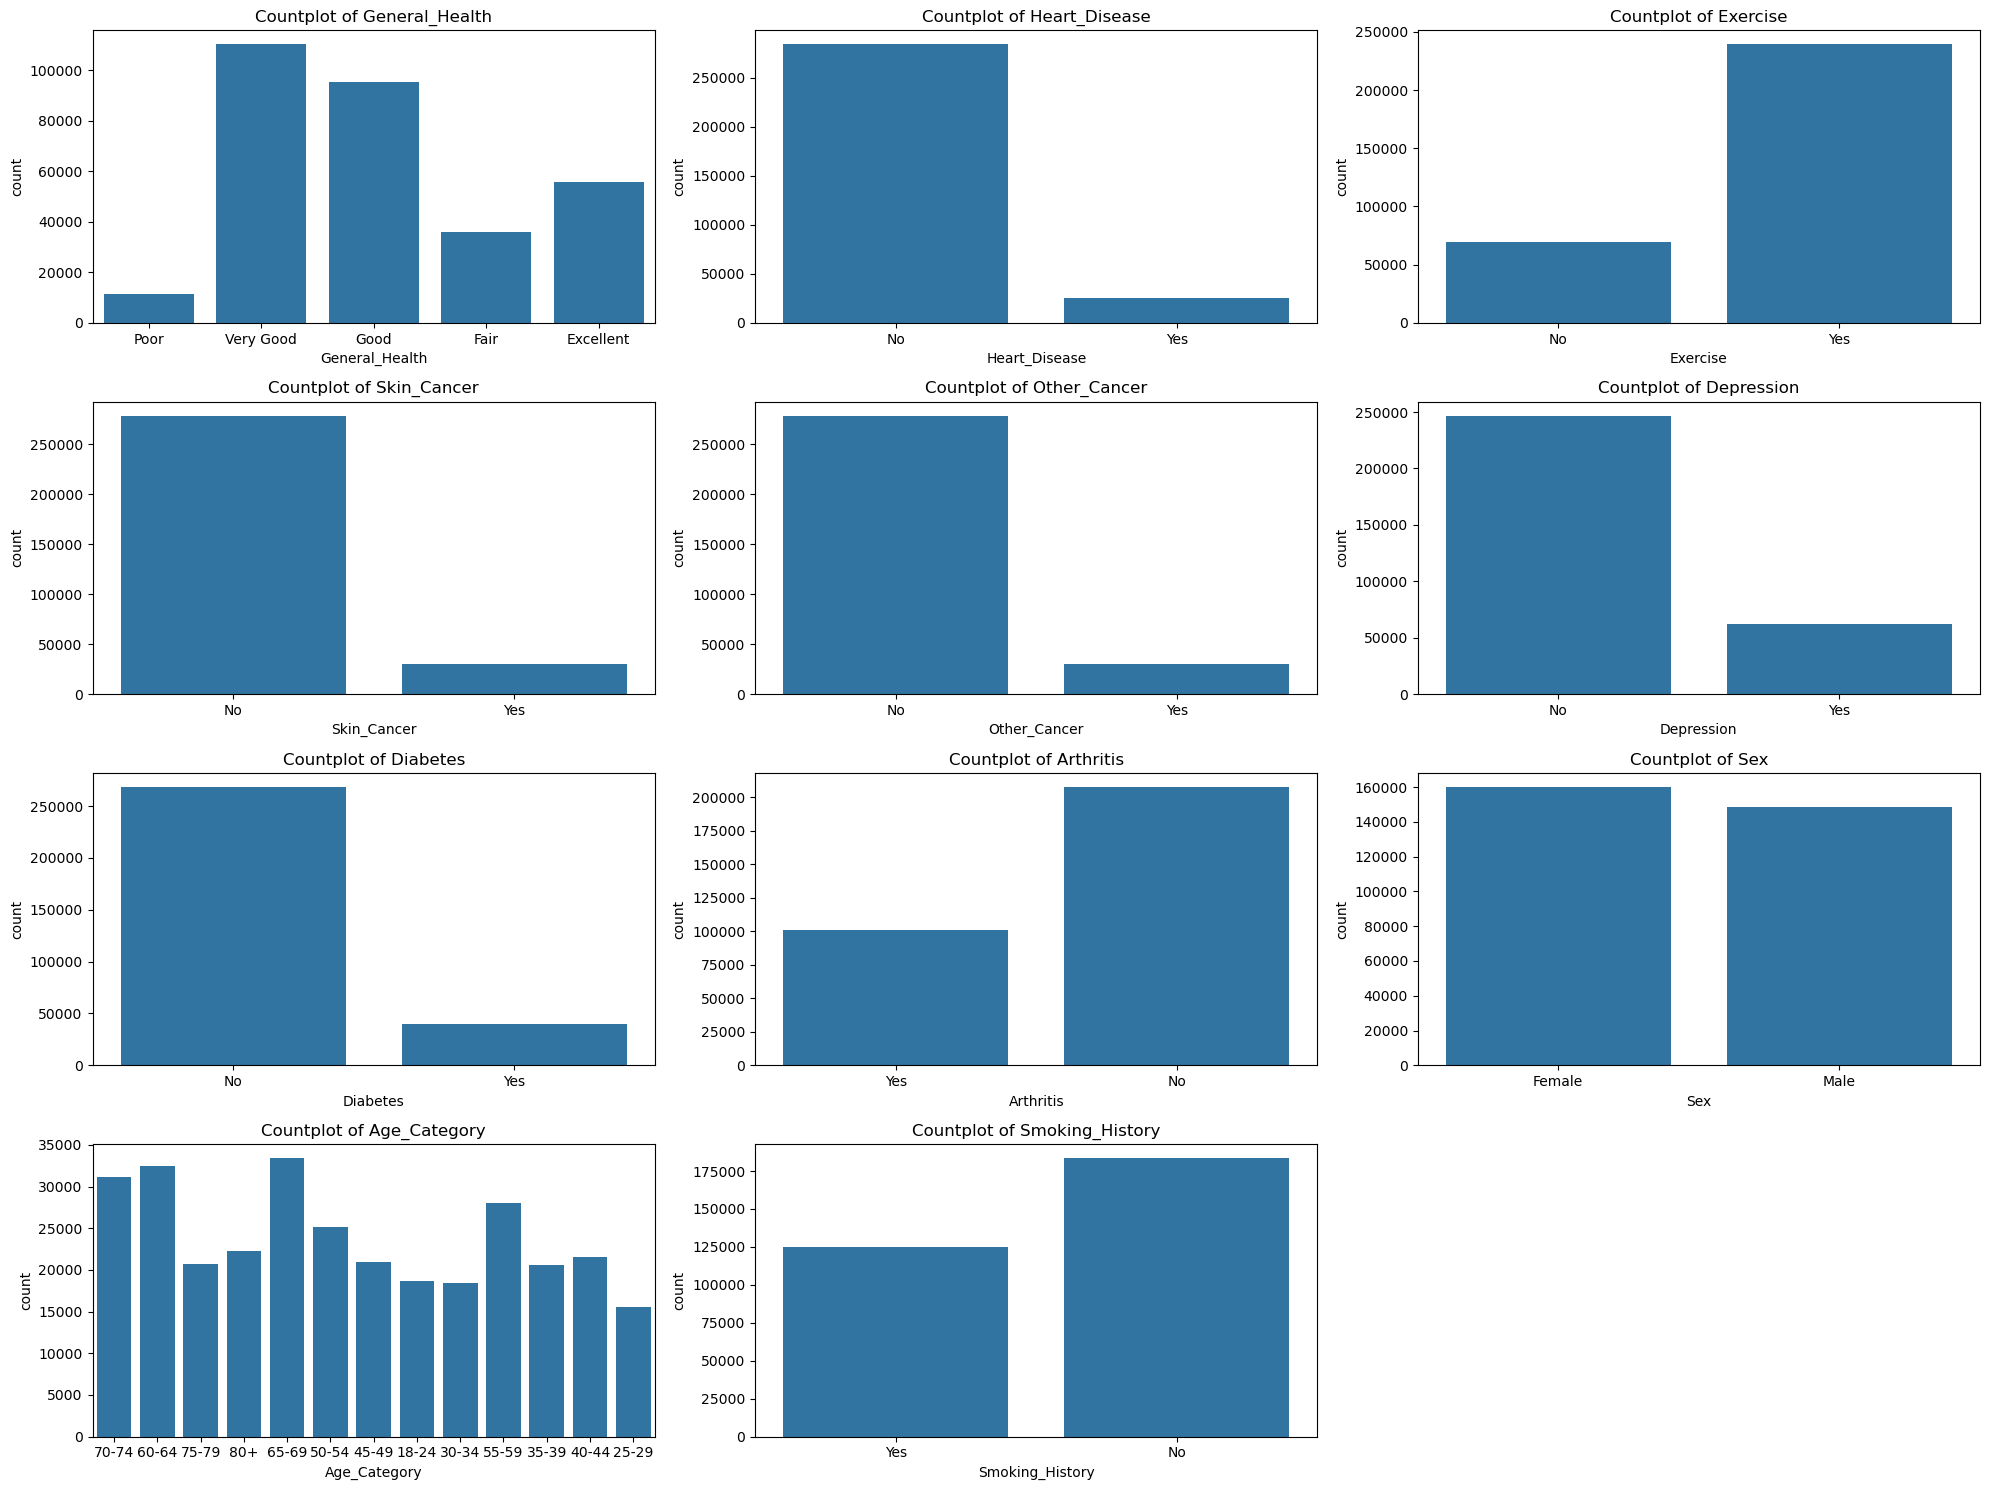

In [18]:
categorical_columns=['General_Health','Heart_Disease','Exercise','Skin_Cancer','Other_Cancer','Depression','Diabetes','Arthritis','Sex','Age_Category','Smoking_History']
rows = 4
cols = 3
plt.figure(figsize=(20, 15))

for i, col in enumerate(categorical_columns,1):
    plt.subplot(rows,cols, i)
    sns.countplot(x=df[col])
    plt.title(f'Countplot of {col}')

plt.tight_layout()
plt.show()


In [19]:
# General Health: The count plot provides a visual representation of the number of individuals in each health rating category, allowing for easy comparison.
# Heart Disease: The count plot shows the frequency of individuals with and without heart disease, highlighting the impact of this condition.
# Exercise : This plot illustrates the number of individuals who exercise regularly versus those who do not, emphasizing lifestyle choices.
# Skin Cancer and Other Cancer: The count plots show the frequency of individuals diagnosed with skin cancer and other cancers, indicating the burden of these diseases.
# Depression and Diabetes: These plots reveal the number of individuals diagnosed with depression and diabetes, providing insights into mental and physical health issues.
# Arthritis: The count plot shows the frequency of arthritis diagnoses, indicating its prevalence.
# Sex: This plot displays the count of males and females in the dataset, which can be important for health analysis.
# Age Category: The count plot reveals the number of individuals in each age category, which can influence health outcomes.
# Smoking History: This plot shows the frequency of individuals with a smoking history, relevant for understanding health risks.

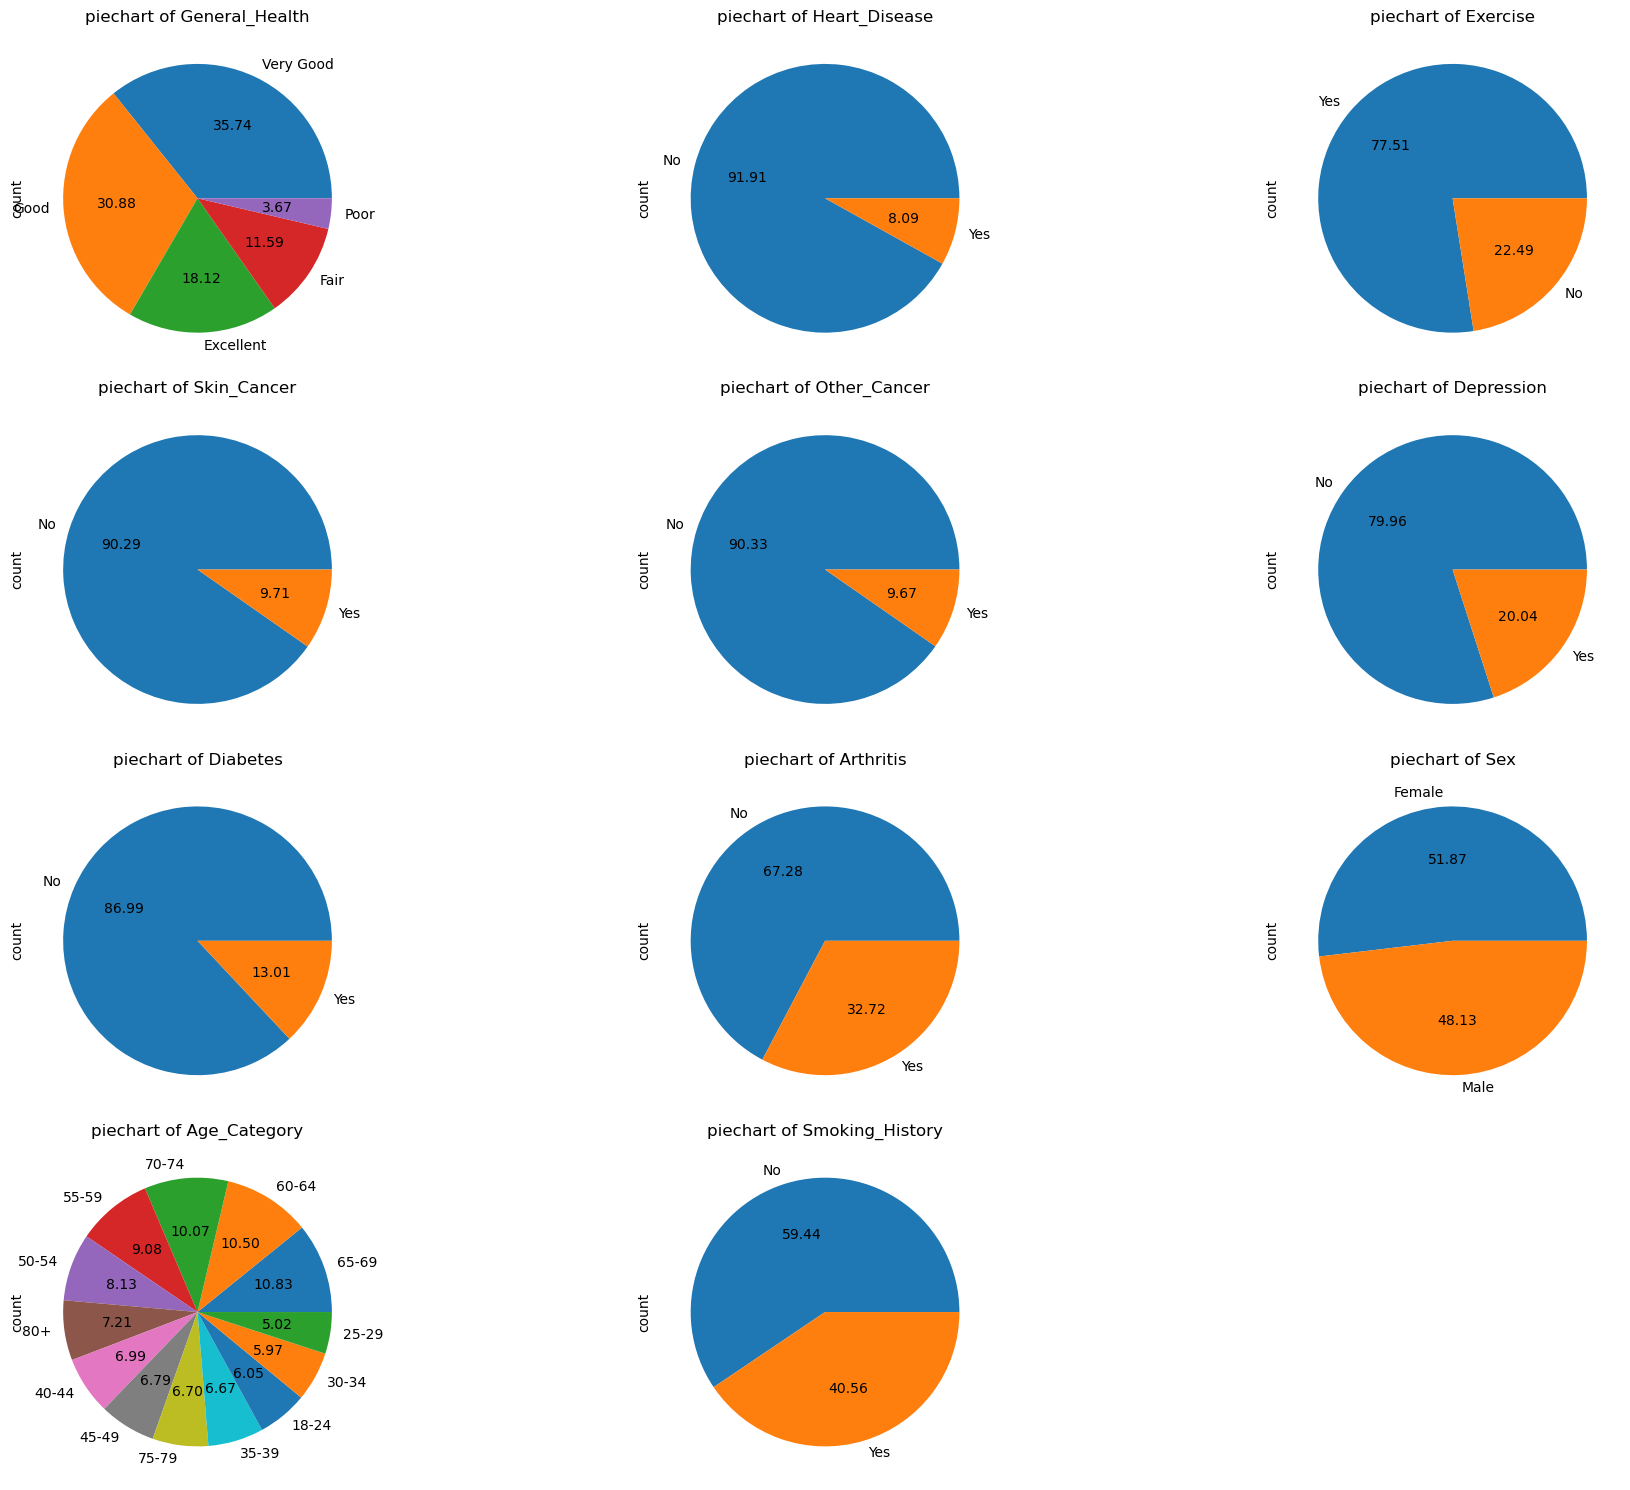

In [20]:
categorical_columns=['General_Health','Heart_Disease','Exercise','Skin_Cancer','Other_Cancer','Depression','Diabetes','Arthritis','Sex','Age_Category','Smoking_History']
rows=4
cols=3
plot_index=1
plt.figure(figsize=(20,15))
for col in categorical_columns:
    plt.subplot(rows,cols,plot_index)
    df[col].value_counts().plot(kind='pie',autopct='%.2f')
    plt.title(f'piechart of {col}')
    plot_index+=1
   

plt.tight_layout()
plt.show()

    

    

In [21]:
# General Health: The distribution shows the proportion of individuals rating their health as excellent, good, fair, or poor, indicating overall health perceptions in the population.
# Heart Disease: The pie chart reveals the percentage of individuals with and without a history of heart disease, highlighting the prevalence of this condition.
# Exercise: This chart illustrates the proportion of individuals who engage in regular exercise versus those who do not, indicating lifestyle choices.
# Skin Cancer and Other Cancer: The charts show the prevalence of skin cancer and other types of cancer, providing insights into cancer rates in the population.
# Depression and Diabetes: These charts indicate the proportions of individuals diagnosed with depression and diabetes, reflecting mental and physical health challenges.
# Arthritis: The pie chart shows the prevalence of arthritis among individuals, indicating a common health issue.
# Sex: This chart displays the gender distribution in the dataset, which can be important for understanding health trends.
# Age Category: The pie chart reveals the distribution of individuals across different age categories, which can influence health outcomes.
# Smoking History: This chart shows the proportion of individuals with a history of smoking, which is relevant for understanding health risks.

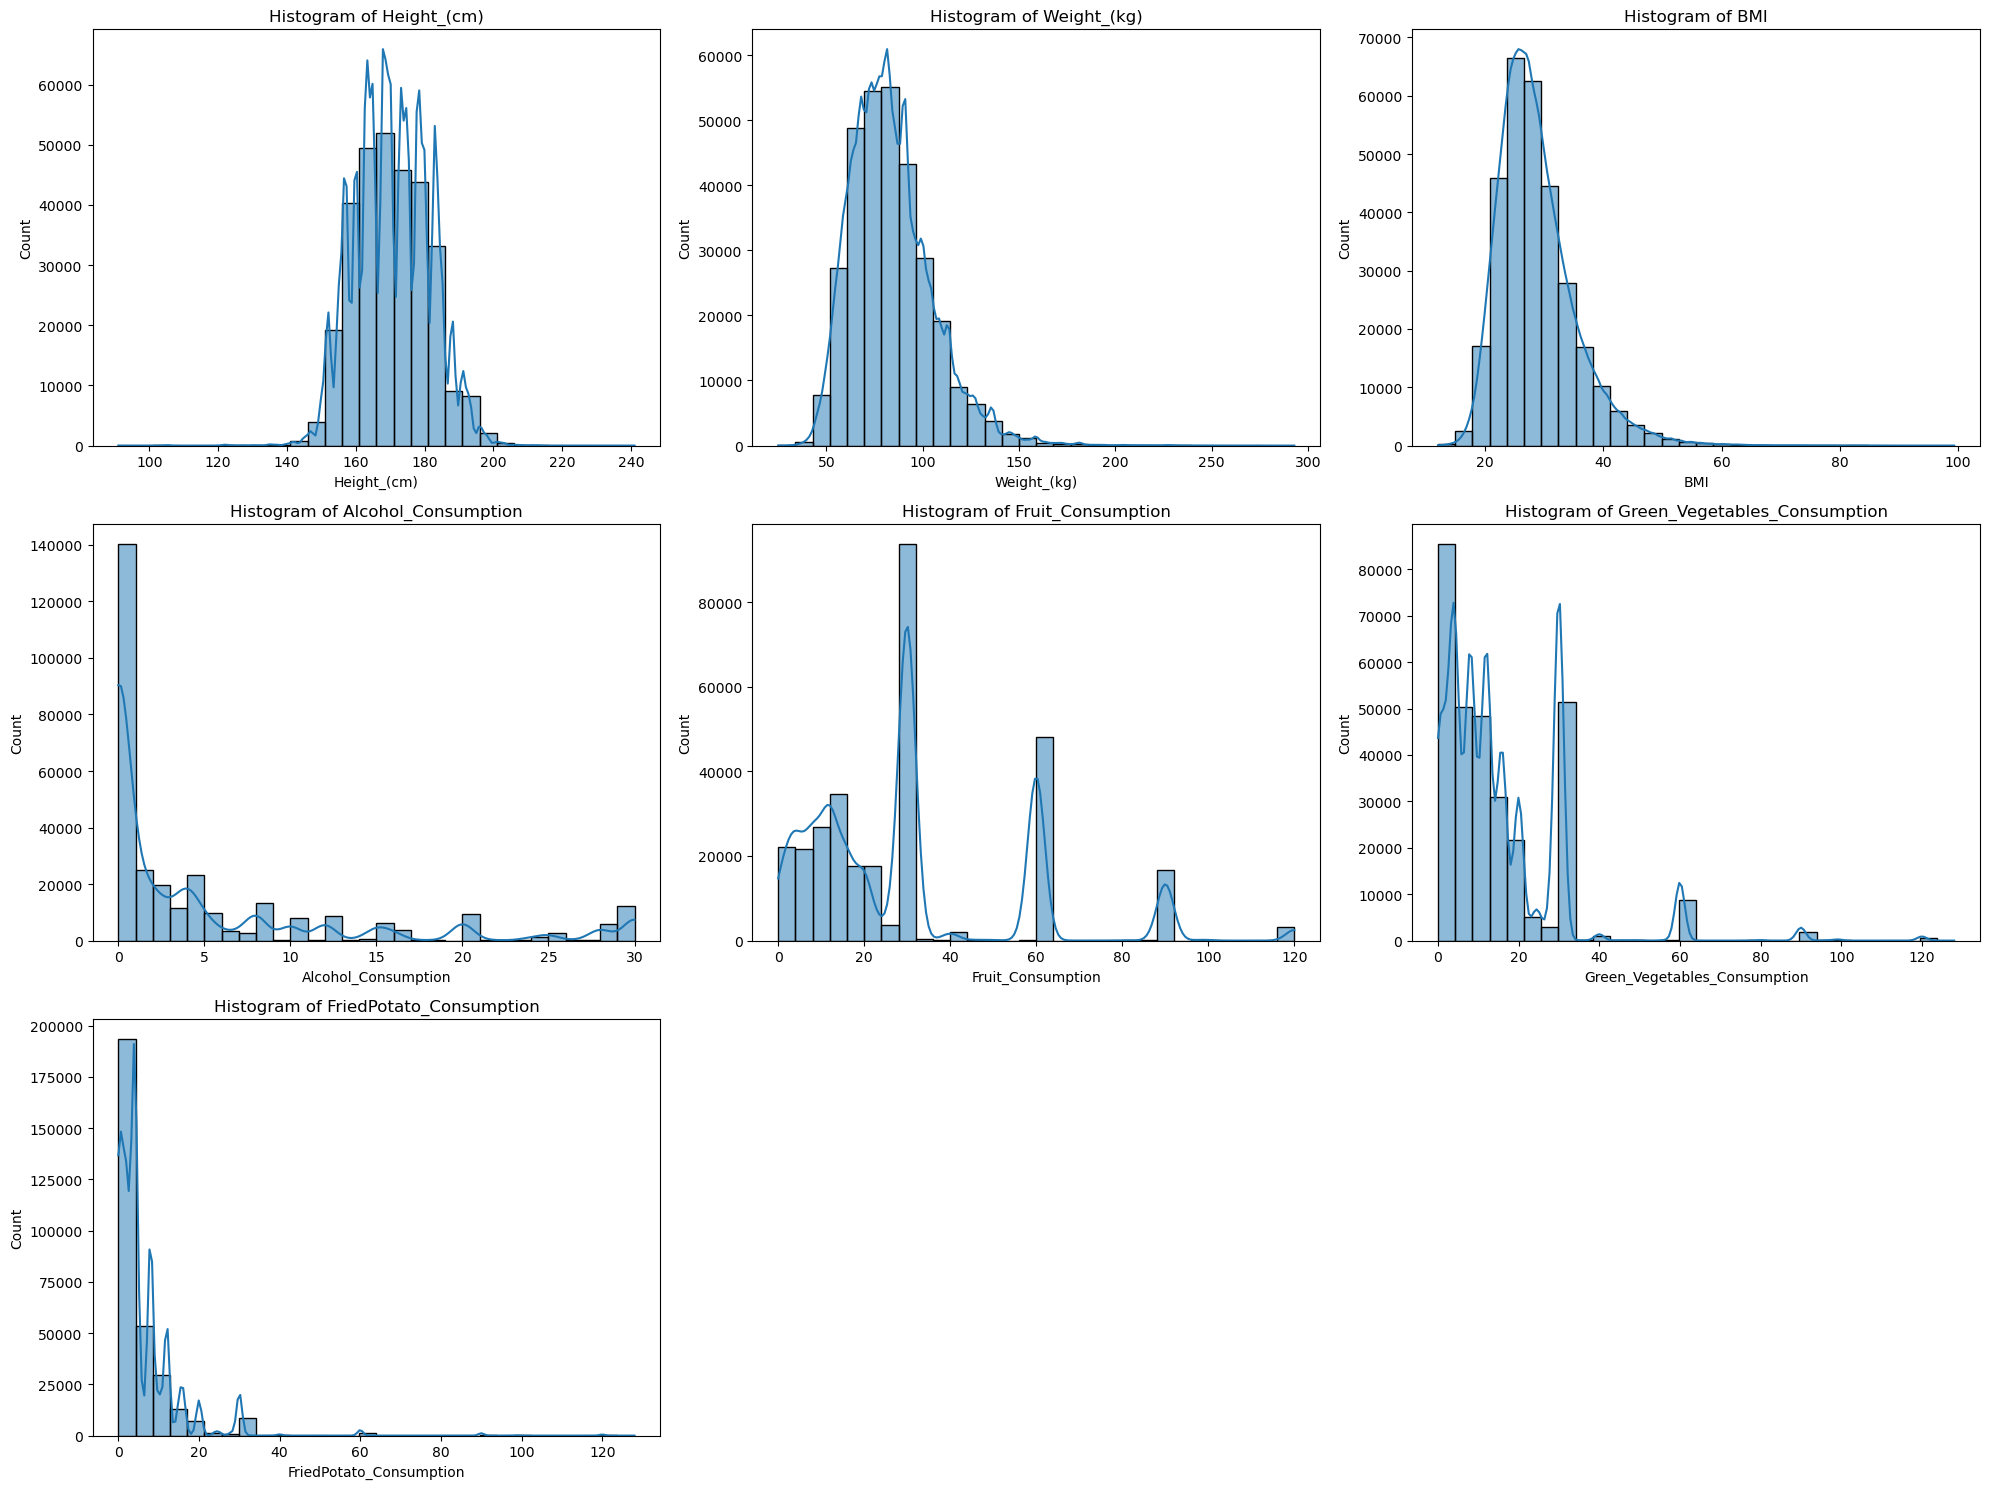

In [22]:
numerical_columns=['Height_(cm)','Weight_(kg)','BMI','Alcohol_Consumption','Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption']
rows=3
cols=3
plot_index=1
plt.figure(figsize=(20,15))
for col in numerical_columns:
    plt.subplot(rows, cols, plot_index) 
    sns.histplot(df[col], kde=True,bins=30)  
    plt.title(f'Histogram of {col}') 
    plot_index += 1  
plt.tight_layout()  
plt.show() 

In [23]:
df[numerical_columns].skew()

Height_(cm)                     0.015311
Weight_(kg)                     1.058204
BMI                             1.376619
Alcohol_Consumption             1.885622
Fruit_Consumption               1.248428
Green_Vegetables_Consumption    2.415608
FriedPotato_Consumption         4.912350
dtype: float64

In [24]:
#Histogram of the numerical columns reveals that:-
#1.Height_(cm)  has almost the normal distribution 
#2.Remaining Columns are right skewed from which 'FriedPotato_Consumption' and 'Green_Vegetables_Consumption' are having higher skewness than others

In [25]:
#Treating Skewness

In [26]:
numerical_columns=['Green_Vegetables_Consumption','FriedPotato_Consumption']
for col in numerical_columns:
    df[col]=np.cbrt(df[col])
    

In [27]:
df[numerical_columns].skew()

Green_Vegetables_Consumption   -0.507872
FriedPotato_Consumption        -0.220551
dtype: float64

<Figure size 1500x1000 with 0 Axes>

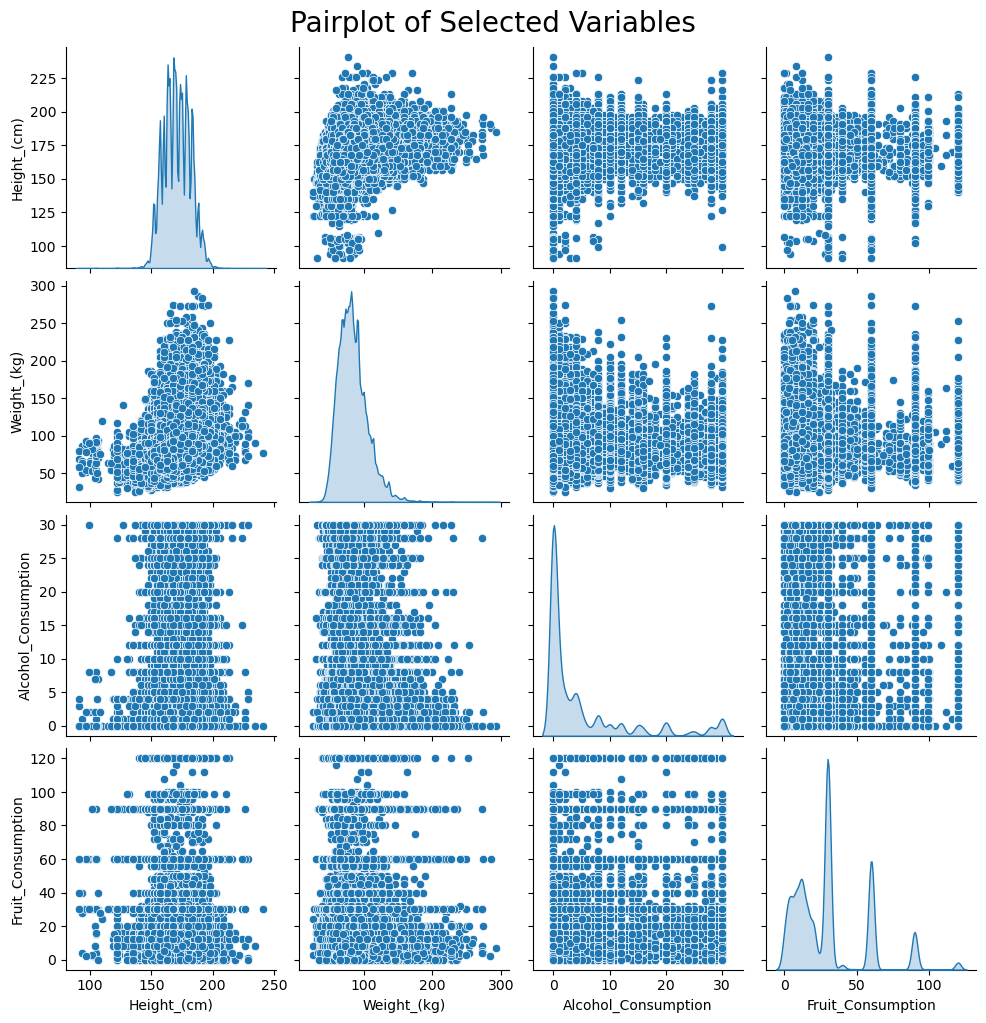

In [28]:
# Multivariate Analysis: Exploring interactions among multiple variables
plt.figure(figsize=(15, 10))

# Creating a pairplot for selected variables
selected_vars = ['General_Health', 'Height_(cm)', 'Weight_(kg)', 'Alcohol_Consumption', 'Fruit_Consumption', 'Exercise']

sns.pairplot(df[selected_vars], diag_kind='kde', markers='o', palette='deep')
plt.suptitle('Pairplot of Selected Variables', y=1.02, fontsize=20)
plt.show()  

In [29]:
# From this visualization, we can infer:

# General Health appears to have a relationship with Exercise and Weight, suggesting that higher exercise levels may correlate with better general health.
# Height and Weight show a positive correlation, which is expected as taller individuals often weigh more.
# Alcohol Consumption and Fruit Consumption may have an inverse relationship, indicating that higher alcohol intake could be associated with lower fruit consumption.

In [30]:
numerical_columns=['Height_(cm)','Weight_(kg)','BMI','Alcohol_Consumption','Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption']
for col in numerical_columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    outliers=df[(df[col]<lower_bound)|(df[col]>upper_bound)]
    print(f'Outliers in {col}={len(outliers)}')

Outliers in Height_(cm)=1055
Outliers in Weight_(kg)=7326
Outliers in BMI=9530
Outliers in Alcohol_Consumption=36147
Outliers in Fruit_Consumption=68225
Outliers in Green_Vegetables_Consumption=2795
Outliers in FriedPotato_Consumption=46463


Identfiying the Outliers

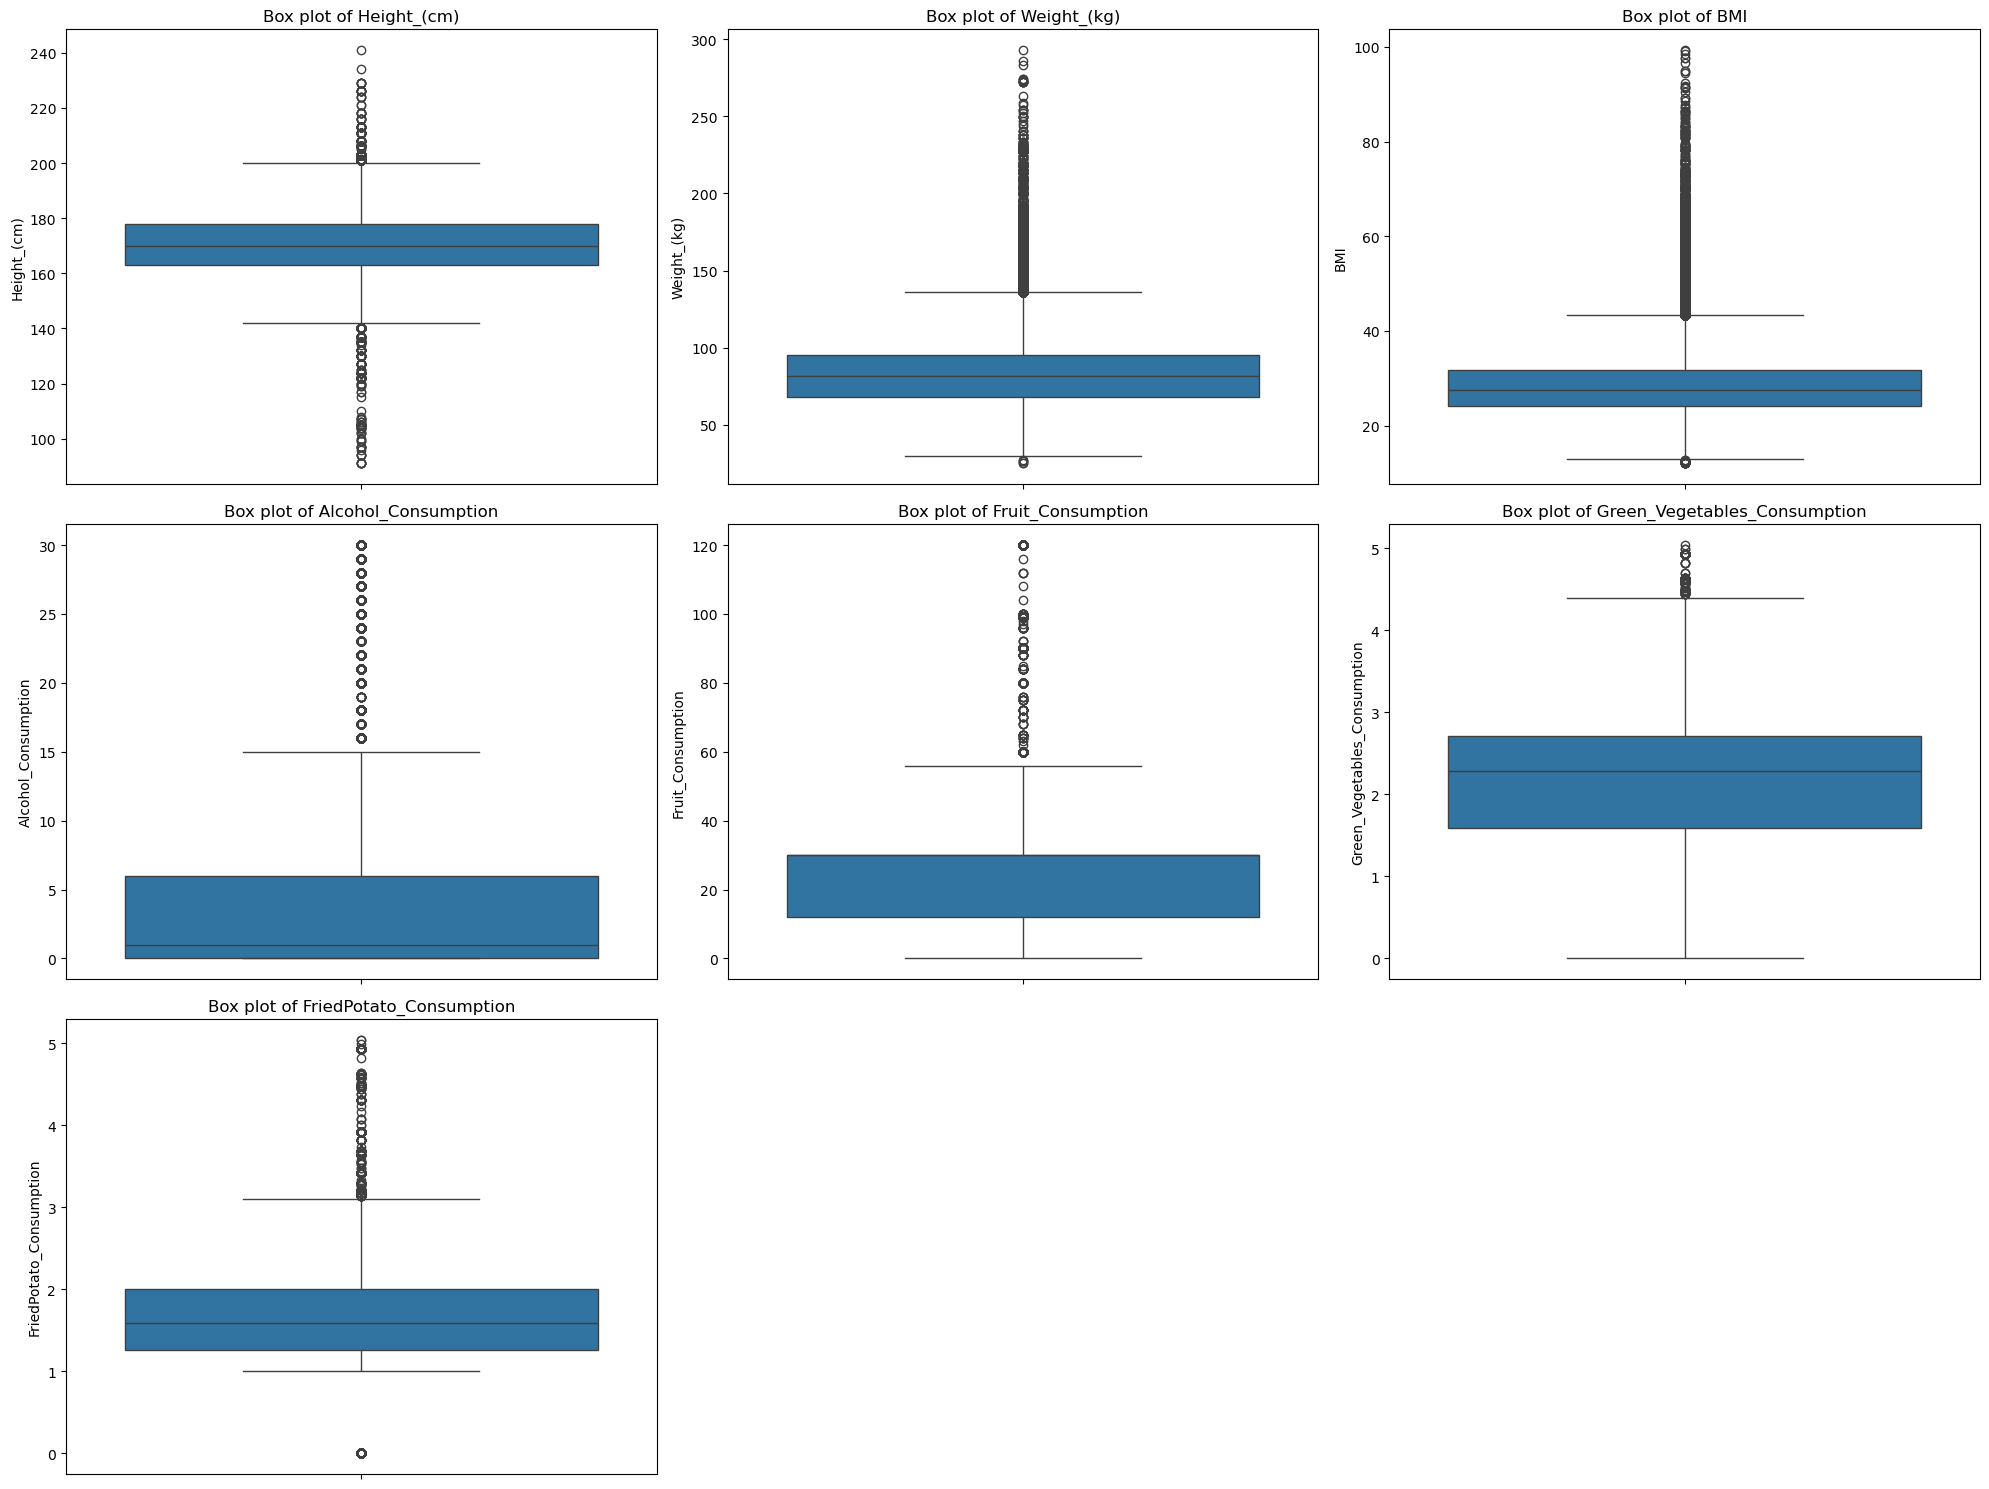

In [31]:
numerical_columns=['Height_(cm)','Weight_(kg)','BMI','Alcohol_Consumption','Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption']
rows=3
cols=3
plot_index=1
plt.figure(figsize=(20,15))
for col in numerical_columns:
    plt.subplot(rows,cols,plot_index)
    sns.boxplot(df[col])
    plt.title(f"Box plot of {col}")
    plot_index+=1
plt.tight_layout()
plt.show()
    

<function matplotlib.pyplot.show(close=None, block=None)>

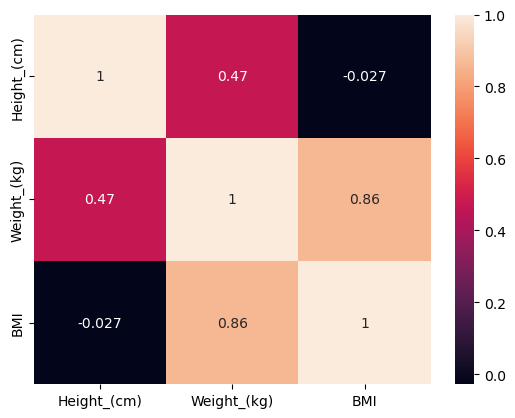

In [32]:
 sns.heatmap(df[['Height_(cm)','Weight_(kg)','BMI']].corr(),annot=True)
 plt.show

In [33]:
 label_enc=LabelEncoder()

In [34]:
 df['Heart_Disease']=label_enc.fit_transform(df['Heart_Disease'])

<function matplotlib.pyplot.show(close=None, block=None)>

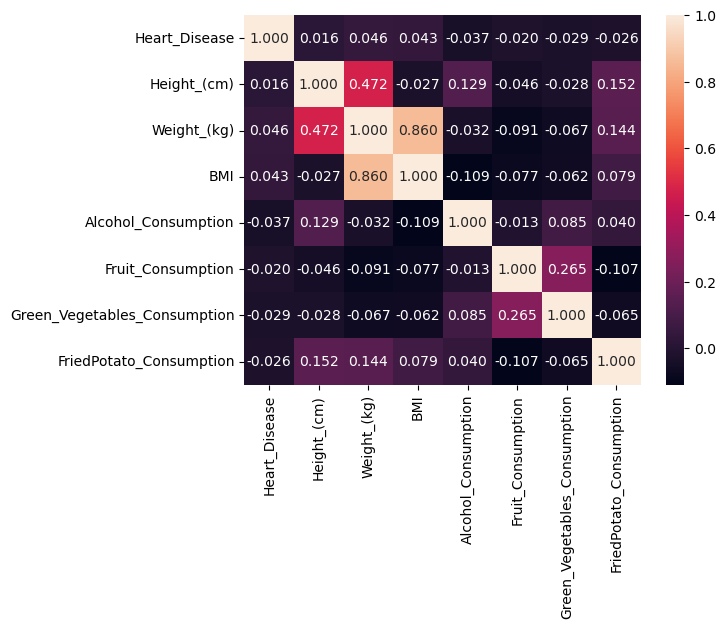

In [35]:
 outliers_columns=['Heart_Disease','Height_(cm)','Weight_(kg)','BMI','Alcohol_Consumption','Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption']
 sns.heatmap(df[outliers_columns].corr(),annot=True,fmt='.3f')

plt.show

In [36]:
 df[outliers_columns].corr()

,Heart_Disease,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
Heart_Disease,1.000000,0.015780,0.045875,0.042666,-0.036569,-0.020055,-0.029004,-0.026069
Height_(cm),0.015780,1.000000,0.472186,-0.027408,0.128835,-0.045911,-0.027628,0.152300
Weight_(kg),0.045875,0.472186,1.000000,0.859699,-0.032373,-0.090612,-0.067101,0.144447
BMI,0.042666,-0.027408,0.859699,1.000000,-0.108684,-0.076611,-0.062379,0.079219
Alcohol_Consumption,-0.036569,0.128835,-0.032373,-0.108684,1.000000,-0.012562,0.084885,0.039868
Fruit_Consumption,-0.020055,-0.045911,-0.090612,-0.076611,-0.012562,1.000000,0.264812,-0.106641
Green_Vegetables_Consumption,-0.029004,-0.027628,-0.067101,-0.062379,0.084885,0.264812,1.000000,-0.064909
FriedPotato_Consumption,-0.026069,0.152300,0.144447,0.079219,0.039868,-0.106641,-0.064909,1.000000


In [37]:
df.drop(['BMI'],axis=1,inplace=True)

In [38]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
308850,Fair,Within the past 5 years,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
308851,Very Good,5 or more years ago,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
308852,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


In [39]:
#We dropped BMI as heatmap reveal that BMI and Weight are highly correlated and BMI has less correlation with the target variable

Treating Outliers

1.Height_(cm)

In [40]:
q1=df['Height_(cm)'].quantile(0.25)
q3=df['Height_(cm)'].quantile(0.75)

In [41]:
iqr=q3-q1

In [42]:
lower_bound=q1-1.5*iqr

In [43]:
lower_bound

140.5

In [44]:
lower_index=np.where(df['Height_(cm)']<lower_bound)
lower_index

(array([   454,    576,   2246,   2376,   2484,   2930,   4032,   4851,
          4970,   5967,   9517,  11131,  15753,  16315,  16785,  16880,
         17643,  17816,  17911,  18105,  18996,  19080,  19175,  20691,
         20808,  20858,  21128,  21144,  21216,  21244,  21331,  21368,
         21516,  21556,  21557,  21871,  21955,  22009,  22189,  22196,
         22357,  22766,  22822,  23371,  23428,  23489,  23539,  23661,
         23820,  23836,  24141,  24148,  25369,  27158,  28472,  29060,
         29353,  29696,  29699,  30023,  31636,  32004,  33506,  33692,
         34698,  35670,  35950,  36426,  36433,  38719,  39464,  40767,
         41285,  42217,  42896,  43187,  43984,  44035,  44166,  44609,
         44616,  44751,  44797,  45065,  45259,  45467,  45859,  45882,
         45945,  46477,  46806,  46856,  47338,  47399,  47974,  48306,
         48435,  49047,  49186,  52180,  53075,  53601,  53676,  53858,
         54087,  57817,  59874,  60240,  61048,  61374,  61509, 

In [45]:
df.drop(df.index[lower_index],inplace=True)

In [46]:
df.reset_index()

,index,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308396,308849,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
308397,308850,Fair,Within the past 5 years,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
308398,308851,Very Good,5 or more years ago,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
308399,308852,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


In [47]:
upper_bound=q3+1.5*iqr

In [48]:
upper_index=np.where(df['Height_(cm)']>upper_bound)
upper_index

(array([   181,   1732,   1762,   1979,   2288,   2511,   3645,   3732,
          3788,   3904,   4009,   4276,   4532,   5288,   5371,   6479,
          6745,   7027,   7220,   7763,   7990,   9147,  10336,  10573,
         10931,  11488,  11635,  12444,  13287,  13649,  13806,  14468,
         14608,  15512,  17135,  17227,  17908,  18022,  18471,  18600,
         18978,  19591,  19822,  19885,  19964,  19969,  20152,  20301,
         21165,  21323,  21758,  22336,  23360,  23533,  24882,  24892,
         24967,  25367,  26586,  26646,  27872,  27997,  28567,  31000,
         31280,  31631,  31633,  33256,  33458,  33543,  33893,  33976,
         35298,  35690,  36342,  36539,  36709,  38133,  38243,  38650,
         39052,  39538,  40623,  41423,  42186,  42713,  42867,  44037,
         44552,  44626,  44848,  45725,  47266,  52754,  53673,  53892,
         54299,  54430,  54657,  55127,  55544,  56349,  56477,  56638,
         56874,  57338,  58602,  58620,  59076,  59596,  59683, 

In [49]:
df.drop(df.index[upper_index],inplace=True)

In [50]:
df.reset_index()

,index,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307794,308849,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
307795,308850,Fair,Within the past 5 years,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
307796,308851,Very Good,5 or more years ago,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
307797,308852,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


<Axes: ylabel='Height_(cm)'>

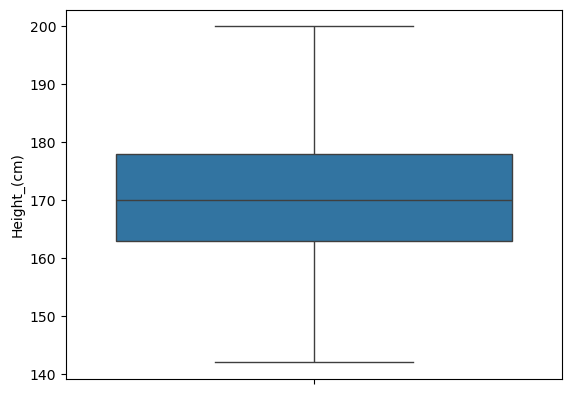

In [51]:
sns.boxplot(df['Height_(cm)'])

2.Weight

In [52]:
q1=df['Weight_(kg)'].quantile(0.25)
q3=df['Weight_(kg)'].quantile(0.75)

In [53]:
iqr=q3-q1
iqr

27.209999999999994

In [54]:
upper_bound=q3+1.5*iqr

In [55]:
upper_index=np.where(df['Weight_(kg)']>upper_bound)
upper_index

(array([     5,     29,    120, ..., 307606, 307625, 307770], dtype=int64),)

In [56]:
df.drop(df.index[upper_index],inplace=True)

In [57]:
df.reset_index()

,index,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300590,308849,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
300591,308850,Fair,Within the past 5 years,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
300592,308851,Very Good,5 or more years ago,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
300593,308852,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


In [58]:
lower_bound=q1-1.5*iqr

In [59]:
lower_index=np.where(df['Weight_(kg)']<lower_bound)
lower_index

(array([179992], dtype=int64),)

In [60]:
df.drop(df.index[lower_index],inplace=True)

In [61]:
df.reset_index()

,index,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300589,308849,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
300590,308850,Fair,Within the past 5 years,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
300591,308851,Very Good,5 or more years ago,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
300592,308852,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


<Axes: ylabel='Weight_(kg)'>

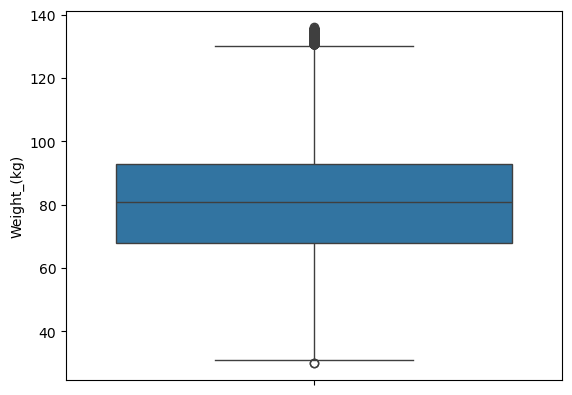

In [62]:
sns.boxplot(df['Weight_(kg)'])

In [63]:
numerical_columns=['Height_(cm)','Weight_(kg)','Alcohol_Consumption','Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption']
for col in numerical_columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    outliers=df[(df[col]<lower_bound)|(df[col]>upper_bound)]
    print(f'Outliers in {col}={len(outliers)}')

Outliers in Height_(cm)=0
Outliers in Weight_(kg)=2131
Outliers in Alcohol_Consumption=35628
Outliers in Fruit_Consumption=66832
Outliers in Green_Vegetables_Consumption=2746
Outliers in FriedPotato_Consumption=45517


3.Alcohol_Consumption

In [64]:
q1=df['Alcohol_Consumption'].quantile(0.25)
q3=df['Alcohol_Consumption'].quantile(0.75)

In [65]:
iqr=q3-q1
iqr

6.0

In [66]:
upper_bound=q3+1.5*iqr

In [67]:
upper_index=np.where(df['Alcohol_Consumption']>upper_bound)
upper_index

(array([    16,     50,     66, ..., 300537, 300556, 300582], dtype=int64),)

In [68]:
df.drop(df.index[upper_index],inplace=True)

In [69]:
df.reset_index()

,index,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264961,308849,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
264962,308850,Fair,Within the past 5 years,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
264963,308851,Very Good,5 or more years ago,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
264964,308852,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


In [70]:
lower_bound=q1-1.5*iqr

In [71]:
lower_index=np.where(df['Alcohol_Consumption']<lower_bound)

In [72]:
lower_index#There are no lower outliers

(array([], dtype=int64),)

4.Fruit_Consumption

In [73]:
q1=df['Fruit_Consumption'].quantile(0.25)
q3=df['Fruit_Consumption'].quantile(0.75)

In [74]:
iqr=q3-q1
iqr

18.0

In [75]:
upper_bound=q3+1.5*iqr

In [76]:
upper_index=np.where(df['Fruit_Consumption']>upper_bound)
upper_index

(array([    18,     28,     33, ..., 264932, 264943, 264945], dtype=int64),)

In [77]:
df.drop(df.index[upper_index],inplace=True)

In [78]:
df.reset_index()

,index,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205475,308849,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
205476,308850,Fair,Within the past 5 years,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
205477,308851,Very Good,5 or more years ago,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
205478,308852,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


In [79]:
lower_bound=q1-1.5*iqr

In [80]:
lower_index=np.where(df['Fruit_Consumption']<lower_bound)

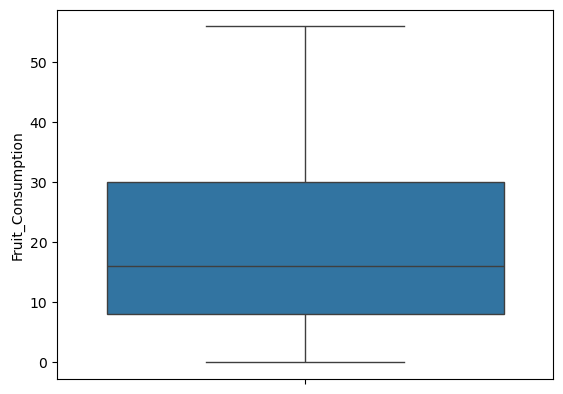

In [81]:
sns.boxplot(df['Fruit_Consumption'])
plt.show()

In [82]:
lower_index#There are no any oultier at lower_index

(array([], dtype=int64),)

5.Greeen_Vegetable_Consumption

In [83]:
q1=df['Green_Vegetables_Consumption'].quantile(0.25)
q3=df['Green_Vegetables_Consumption'].quantile(0.75)

In [84]:
iqr=q3-q1
iqr

1.1270165646267074

In [85]:
upper_bound=q3+1.5*iqr

In [86]:
upper_index=np.where(df['Green_Vegetables_Consumption']>upper_bound)

In [87]:
upper_index

(array([   489,    582,    635, ..., 204771, 205095, 205450], dtype=int64),)

In [88]:
df.drop(df.index[upper_index],inplace=True)

In [89]:
df.reset_index()

,index,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204385,308849,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
204386,308850,Fair,Within the past 5 years,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
204387,308851,Very Good,5 or more years ago,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
204388,308852,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


In [90]:
lower_bound=q1-1.5*iqr

In [91]:
lower_index=np.where(df['Green_Vegetables_Consumption']<lower_bound)

In [92]:
lower_index#There are no any outliers at lower index

(array([], dtype=int64),)

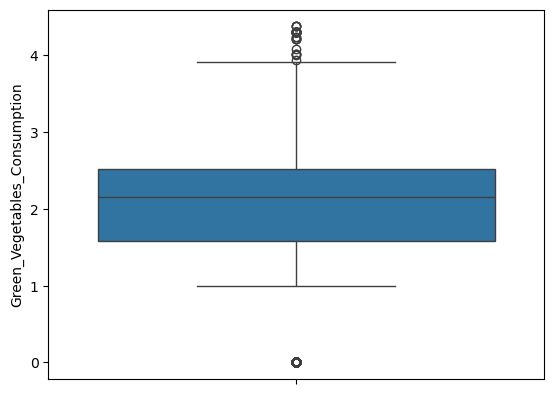

In [93]:
sns.boxplot(df['Green_Vegetables_Consumption'])
plt.show()

6.FriedPotato_Consumption

In [94]:
q1=df['FriedPotato_Consumption'].quantile(0.25)
q3=df['FriedPotato_Consumption'].quantile(0.75)

In [95]:
iqr=q3-q1
iqr

0.740078950105127

In [96]:
upper_bound=q3+1.5*iqr

In [97]:
upper_index=np.where(df['FriedPotato_Consumption']>upper_bound)

In [98]:
upper_index

(array([   555,    643,    696, ..., 200660, 200752, 201468], dtype=int64),)

In [99]:
df.drop(df.index[upper_index],inplace=True)

In [100]:
df.reset_index()

,index,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203169,308849,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
203170,308850,Fair,Within the past 5 years,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
203171,308851,Very Good,5 or more years ago,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
203172,308852,Very Good,Within the past year,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


In [101]:
lower_bound=q1-1.5*iqr

In [102]:
lower_index=np.where(df['FriedPotato_Consumption']<lower_bound)
lower_index

(array([     4,      5,     13, ..., 203168, 203169, 203172], dtype=int64),)

In [103]:
len(lower_index[0])

27187

In [104]:
lower_index_values = lower_index[0] 
values_at_lower_index = df.iloc[lower_index_values] 
print(values_at_lower_index['FriedPotato_Consumption'])


4         0.0
6         0.0
14        0.0
26        0.0
33        0.0
         ... 
308843    0.0
308847    0.0
308848    0.0
308849    0.0
308852    0.0
Name: FriedPotato_Consumption, Length: 27187, dtype: float64


In [105]:
#The values of these outlier are all zero so we have decided to keep these values in our dataset

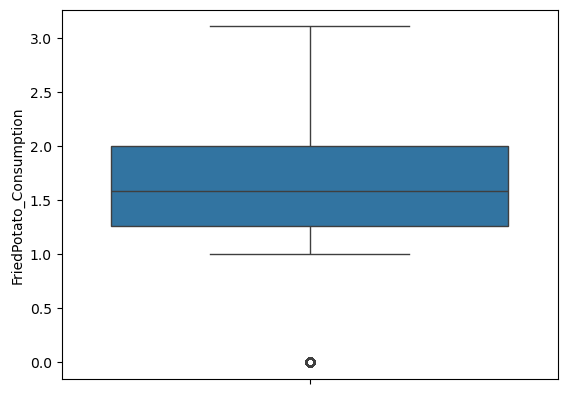

In [106]:
sns.boxplot(df['FriedPotato_Consumption'])
plt.show()

After treating outliers

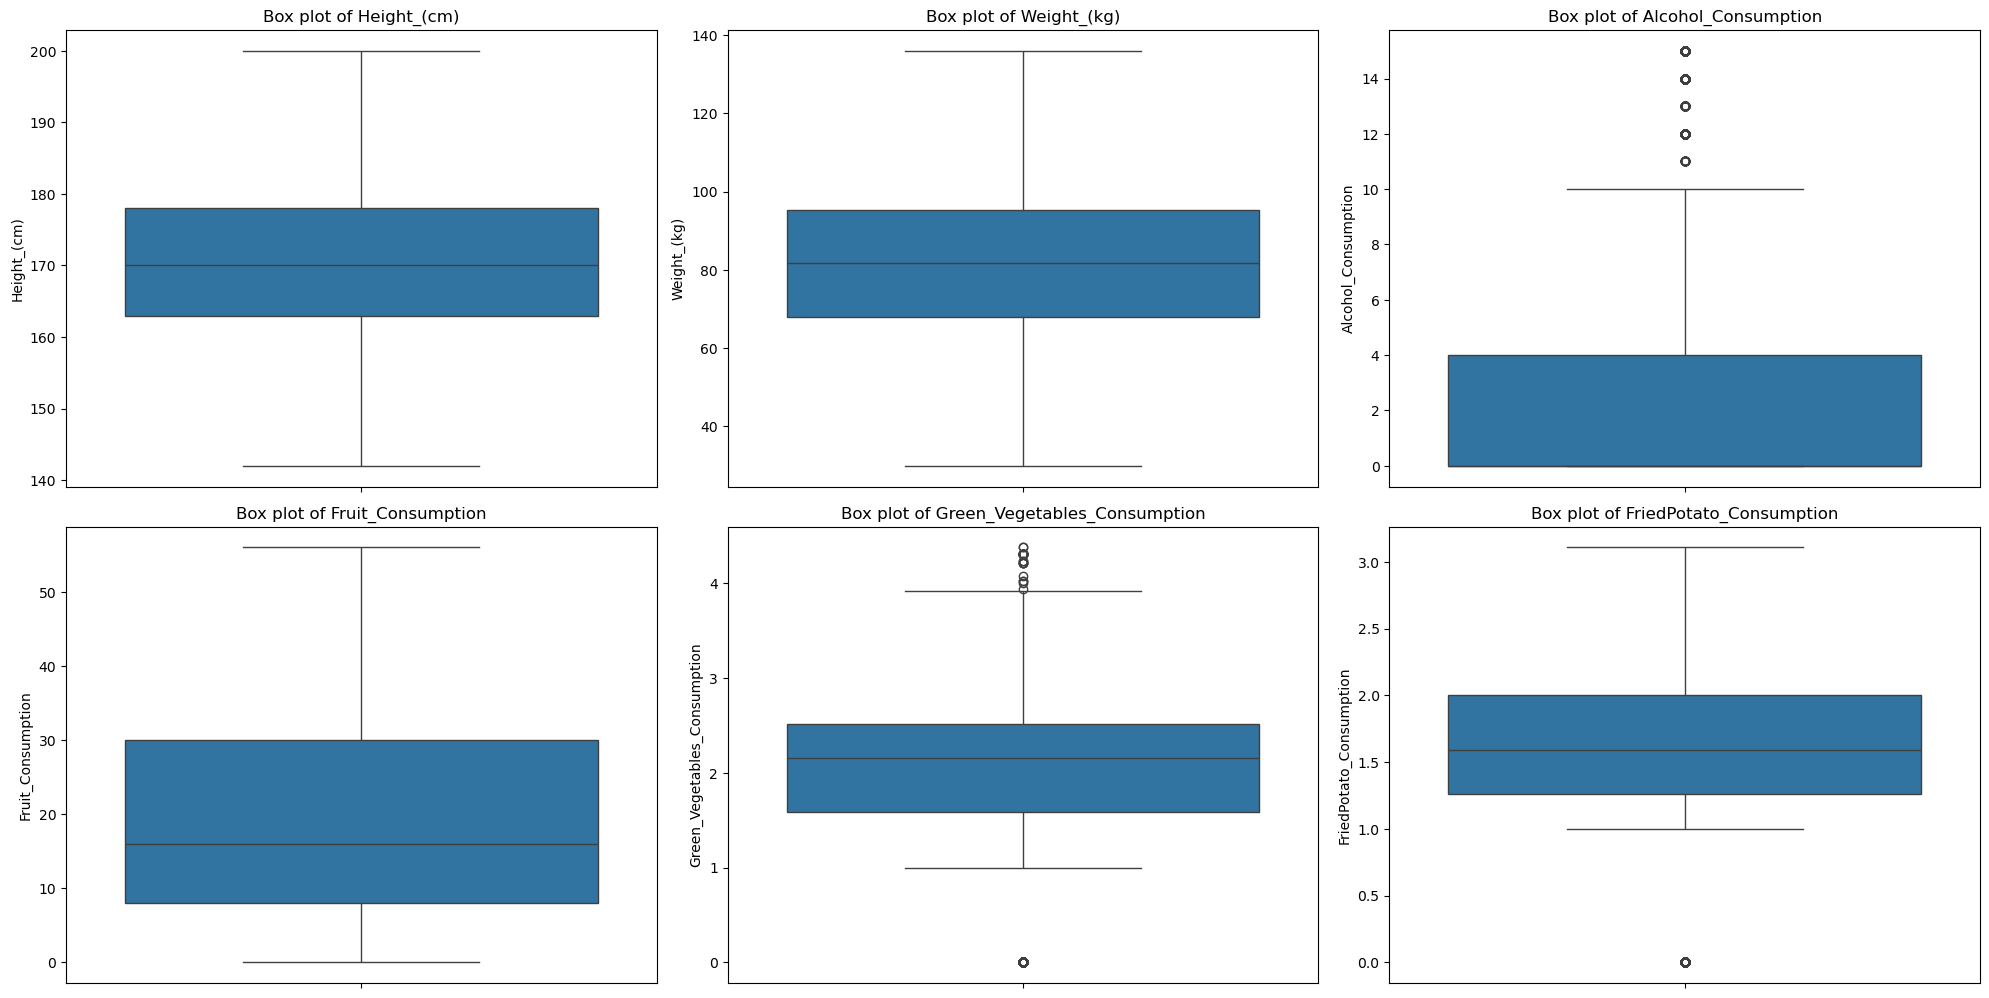

In [107]:
numerical_columns=['Height_(cm)','Weight_(kg)','Alcohol_Consumption','Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption']
rows=3
cols=3
plot_index=1
plt.figure(figsize=(20,15))
for col in numerical_columns:
    plt.subplot(rows,cols,plot_index)
    sns.boxplot(df[col])
    plt.title(f"Box plot of {col}")
    plot_index+=1
plt.tight_layout()
plt.show()

Bivariate analysis

<Figure size 1200x600 with 0 Axes>

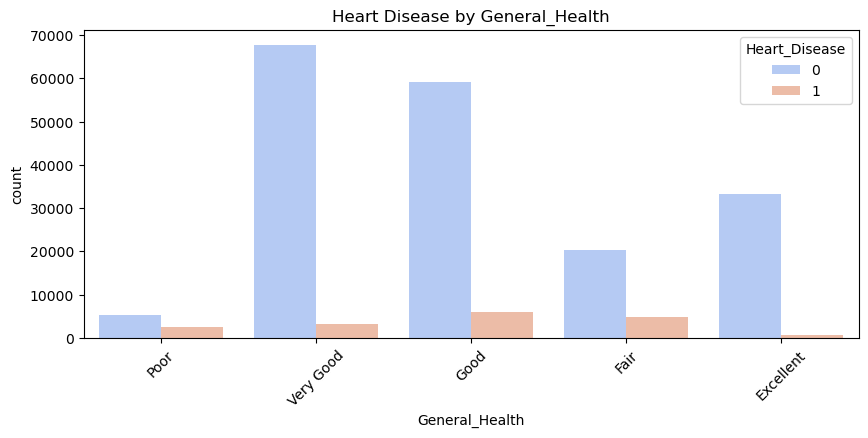

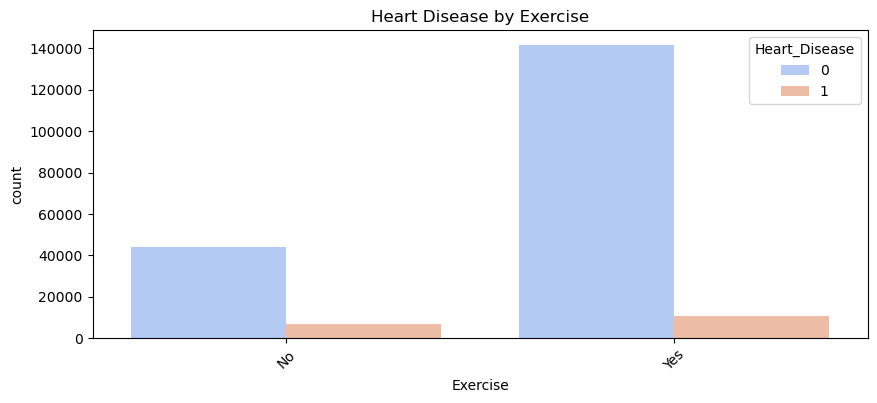

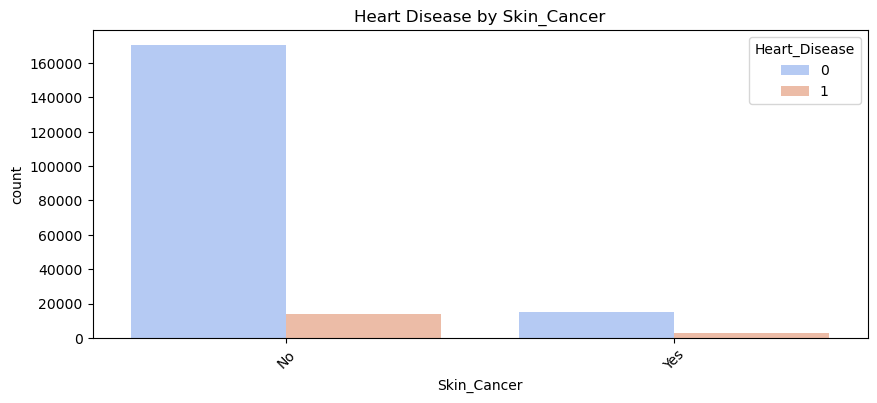

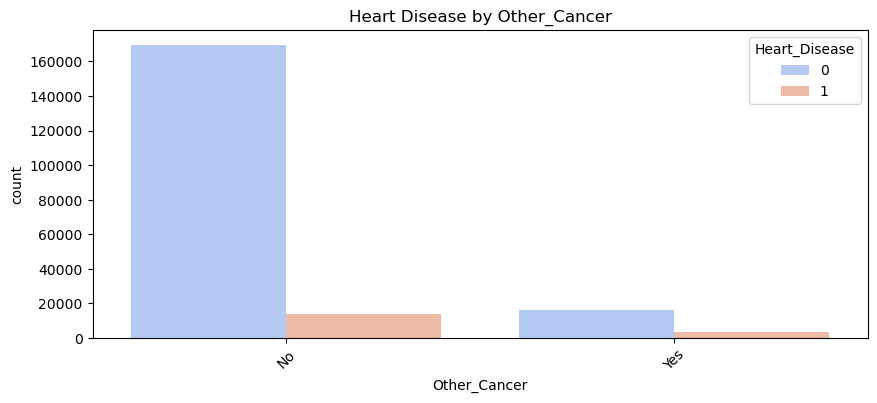

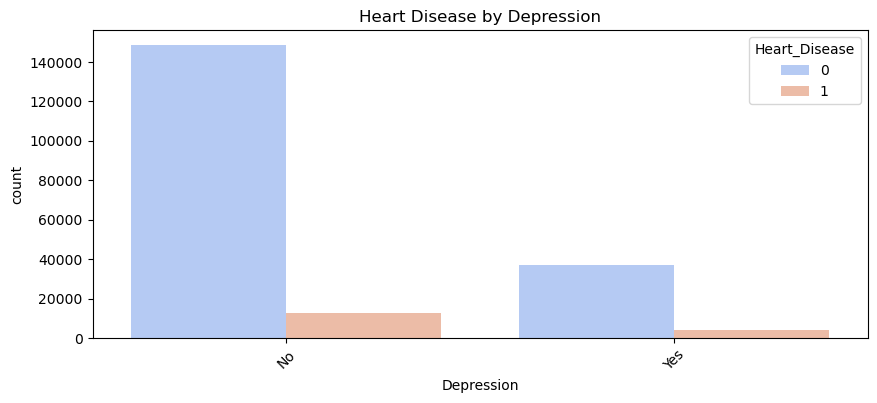

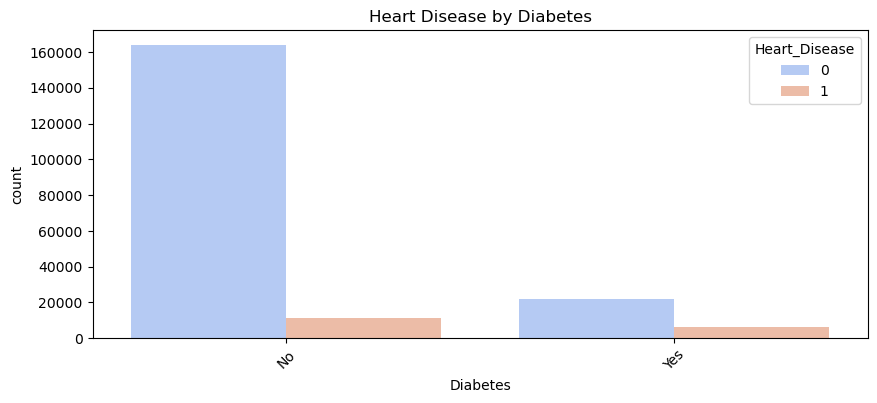

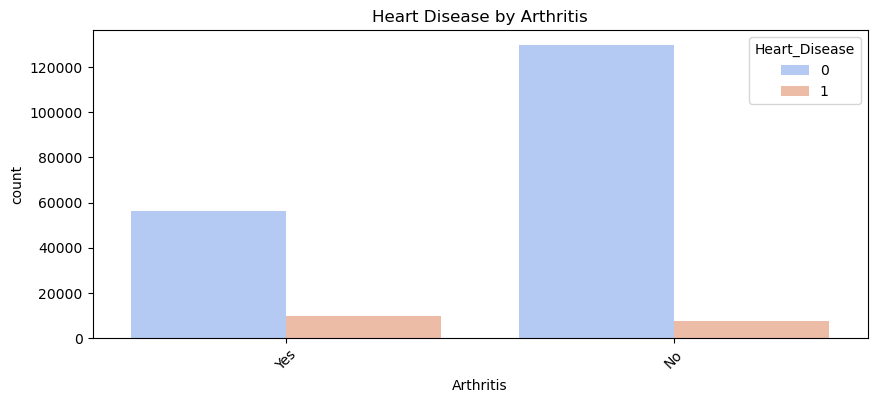

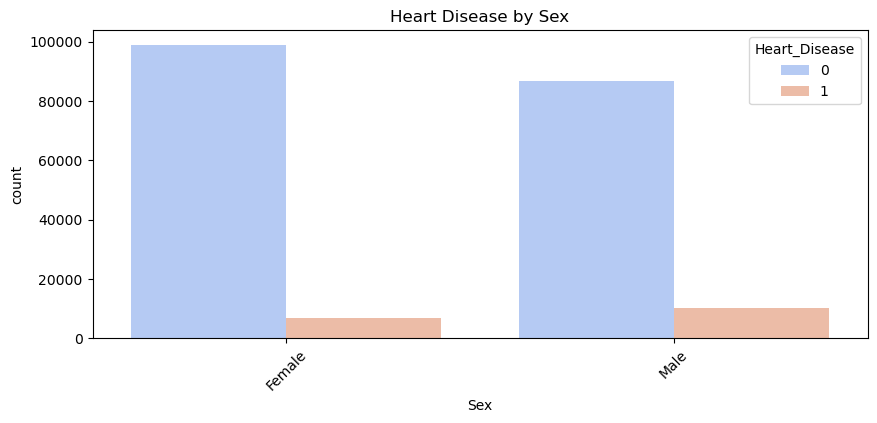

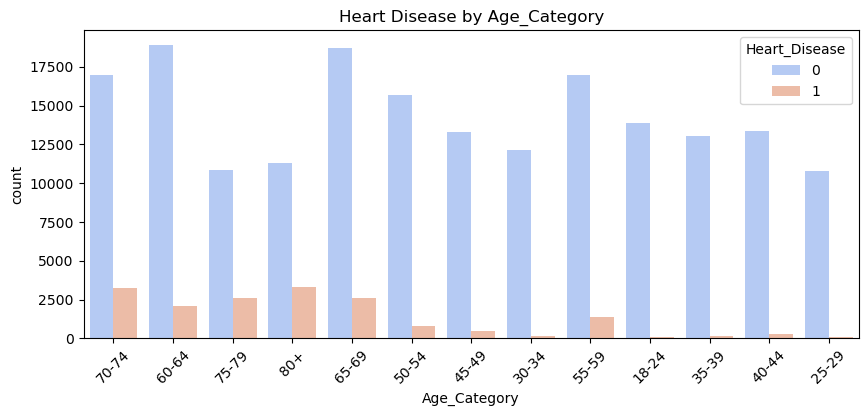

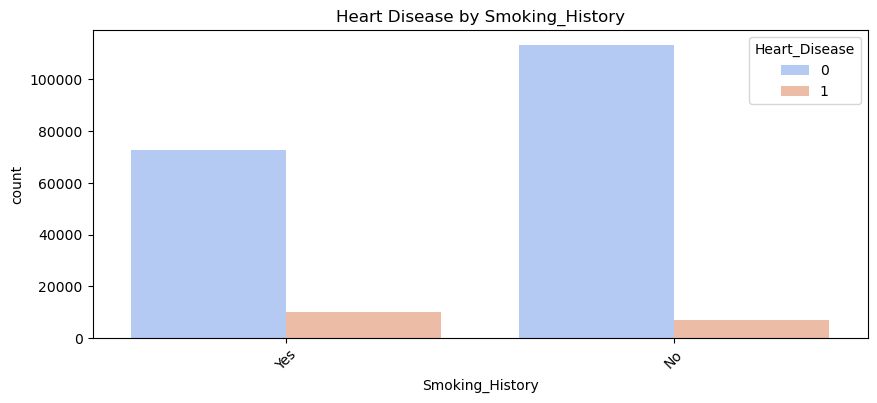

In [108]:


categorical_cols = ['General_Health','Exercise','Skin_Cancer','Other_Cancer','Depression','Diabetes','Arthritis','Sex','Age_Category','Smoking_History']
numerical_cols = ['Height_(cm)','Weight_(kg)','Alcohol_Consumption','Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption']
plt.figure(figsize=(12, 6))
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, hue='Heart_Disease', data=df, palette='coolwarm')
    plt.xticks(rotation=45)
    plt.title(f'Heart Disease by {col}')
    plt.show()




<Figure size 1000x400 with 0 Axes>

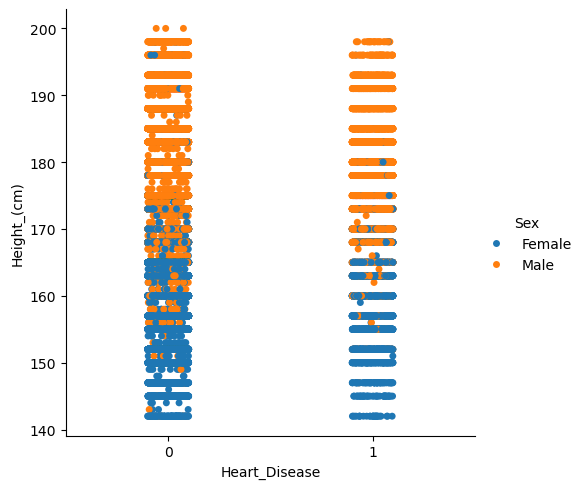

In [109]:
plt.figure(figsize=(10, 4))
sns.catplot(x='Heart_Disease', y='Height_(cm)',hue='Sex' ,data=df)
plt.show()


In [110]:
# The bivariate analysis shows clear differences in distributions for categorical and numerical variables with respect to Heart_Disease. Key observations:

# Some categories (e.g., Poor General Health, Diabetes, Smoking History) show higher heart disease prevalence.

# Higher Weight, Age, and Fried Potato Consumption seem linked to heart disease.

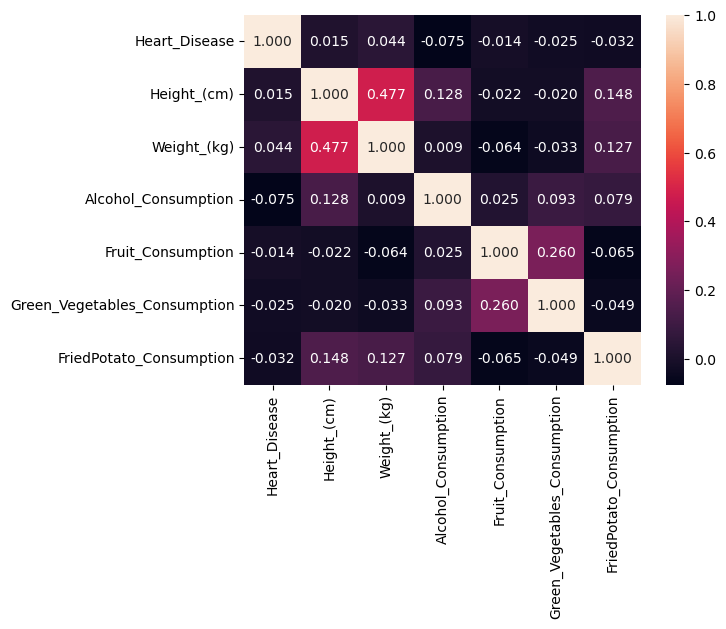

In [111]:
numerical_cols = ['Heart_Disease','Height_(cm)','Weight_(kg)','Alcohol_Consumption','Fruit_Consumption','Green_Vegetables_Consumption','FriedPotato_Consumption']
sns.heatmap(df[numerical_cols].corr(),annot=True,fmt='.3f')
plt.show()

In [112]:
# Age, Weight, and Diabetes have notable positive correlations with Heart_Disease.

# Exercise and Alcohol Consumption show slight negative correlations, suggesting potential protective effects.

Encoding

In [113]:
#Ordinal Encoding

In [114]:
Ordinal_enc=OrdinalEncoder()

In [115]:
df['General_Health']=Ordinal_enc.fit_transform(df[['General_Health']])

In [116]:
df['Checkup']=Ordinal_enc.fit_transform(df[['Checkup']])

In [117]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,3.0,2.0,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,Yes,0,30,2.519842,2.289428
1,4.0,4.0,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,No,0,30,0.000000,1.587401
2,4.0,4.0,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,No,4,12,1.442250,2.519842
3,3.0,4.0,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,No,0,30,3.107233,2.000000
4,2.0,4.0,No,0,No,No,No,No,No,Male,80+,191,88.45,Yes,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,4.0,4.0,Yes,0,No,No,No,No,No,Male,25-29,168,81.65,No,4,30,2.000000,0.000000
308850,1.0,3.0,Yes,0,No,No,No,Yes,No,Male,65-69,180,69.85,No,8,15,3.914868,1.587401
308851,4.0,0.0,Yes,0,No,No,Yes,No,No,Female,30-34,157,61.23,Yes,4,40,2.000000,1.587401
308852,4.0,4.0,Yes,0,No,No,No,No,No,Male,65-69,183,79.38,No,3,30,2.289428,0.000000


In [118]:
#Binary Encoding

In [119]:
Binary_enc=BinaryEncoder()

In [120]:
Binary_encoded=Binary_enc.fit_transform(df[['Exercise','Skin_Cancer','Other_Cancer','Depression','Diabetes','Sex','Arthritis','Smoking_History']])

In [121]:
Binary_encoded

,Exercise_0,Exercise_1,Skin_Cancer_0,Skin_Cancer_1,Other_Cancer_0,Other_Cancer_1,Depression_0,Depression_1,Diabetes_0,Diabetes_1,Sex_0,Sex_1,Arthritis_0,Arthritis_1,Smoking_History_0,Smoking_History_1
0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
1,0,1,0,1,0,1,0,1,1,0,0,1,1,0,1,0
2,1,0,0,1,0,1,0,1,1,0,0,1,1,0,1,0
3,1,0,0,1,0,1,0,1,1,0,1,0,1,0,1,0
4,0,1,0,1,0,1,0,1,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,1,0,0,1,0,1,0,1,0,1,1,0,1,0,1,0
308850,1,0,0,1,0,1,0,1,1,0,1,0,1,0,1,0
308851,1,0,0,1,0,1,1,0,0,1,0,1,1,0,0,1
308852,1,0,0,1,0,1,0,1,0,1,1,0,1,0,1,0


In [122]:
Binary_encoded.drop(['Exercise_1','Skin_Cancer_1','Other_Cancer_1','Depression_1','Diabetes_1','Sex_1','Arthritis_1','Smoking_History_1',],axis=1,inplace=True)

In [123]:
Binary_encoded

,Exercise_0,Skin_Cancer_0,Other_Cancer_0,Depression_0,Diabetes_0,Sex_0,Arthritis_0,Smoking_History_0
0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,1,1
2,1,0,0,0,1,0,1,1
3,1,0,0,0,1,1,1,1
4,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...
308849,1,0,0,0,0,1,1,1
308850,1,0,0,0,1,1,1,1
308851,1,0,0,1,0,0,1,0
308852,1,0,0,0,0,1,1,1


In [124]:
df.drop(['Exercise','Skin_Cancer','Depression','Diabetes','Sex','Arthritis','Smoking_History','Other_Cancer'],axis=1,inplace=True)

In [125]:
df

,General_Health,Checkup,Heart_Disease,Age_Category,Height_(cm),Weight_(kg),Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,3.0,2.0,0,70-74,150,32.66,0,30,2.519842,2.289428
1,4.0,4.0,1,70-74,165,77.11,0,30,0.000000,1.587401
2,4.0,4.0,0,60-64,163,88.45,4,12,1.442250,2.519842
3,3.0,4.0,1,75-79,180,93.44,0,30,3.107233,2.000000
4,2.0,4.0,0,80+,191,88.45,0,8,1.587401,0.000000
...,...,...,...,...,...,...,...,...,...,...
308849,4.0,4.0,0,25-29,168,81.65,4,30,2.000000,0.000000
308850,1.0,3.0,0,65-69,180,69.85,8,15,3.914868,1.587401
308851,4.0,0.0,0,30-34,157,61.23,4,40,2.000000,1.587401
308852,4.0,4.0,0,65-69,183,79.38,3,30,2.289428,0.000000


In [126]:
df_encoded=pd.concat([df,Binary_encoded],axis=1)

In [127]:
df_encoded

,General_Health,Checkup,Heart_Disease,Age_Category,Height_(cm),Weight_(kg),Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_0,Skin_Cancer_0,Other_Cancer_0,Depression_0,Diabetes_0,Sex_0,Arthritis_0,Smoking_History_0
0,3.0,2.0,0,70-74,150,32.66,0,30,2.519842,2.289428,0,0,0,0,0,0,0,0
1,4.0,4.0,1,70-74,165,77.11,0,30,0.000000,1.587401,0,0,0,0,1,0,1,1
2,4.0,4.0,0,60-64,163,88.45,4,12,1.442250,2.519842,1,0,0,0,1,0,1,1
3,3.0,4.0,1,75-79,180,93.44,0,30,3.107233,2.000000,1,0,0,0,1,1,1,1
4,2.0,4.0,0,80+,191,88.45,0,8,1.587401,0.000000,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,4.0,4.0,0,25-29,168,81.65,4,30,2.000000,0.000000,1,0,0,0,0,1,1,1
308850,1.0,3.0,0,65-69,180,69.85,8,15,3.914868,1.587401,1,0,0,0,1,1,1,1
308851,4.0,0.0,0,30-34,157,61.23,4,40,2.000000,1.587401,1,0,0,1,0,0,1,0
308852,4.0,4.0,0,65-69,183,79.38,3,30,2.289428,0.000000,1,0,0,0,0,1,1,1


In [128]:
df_encoded['Age_Category']=Ordinal_enc.fit_transform(df_encoded[['Age_Category']])

<Axes: >

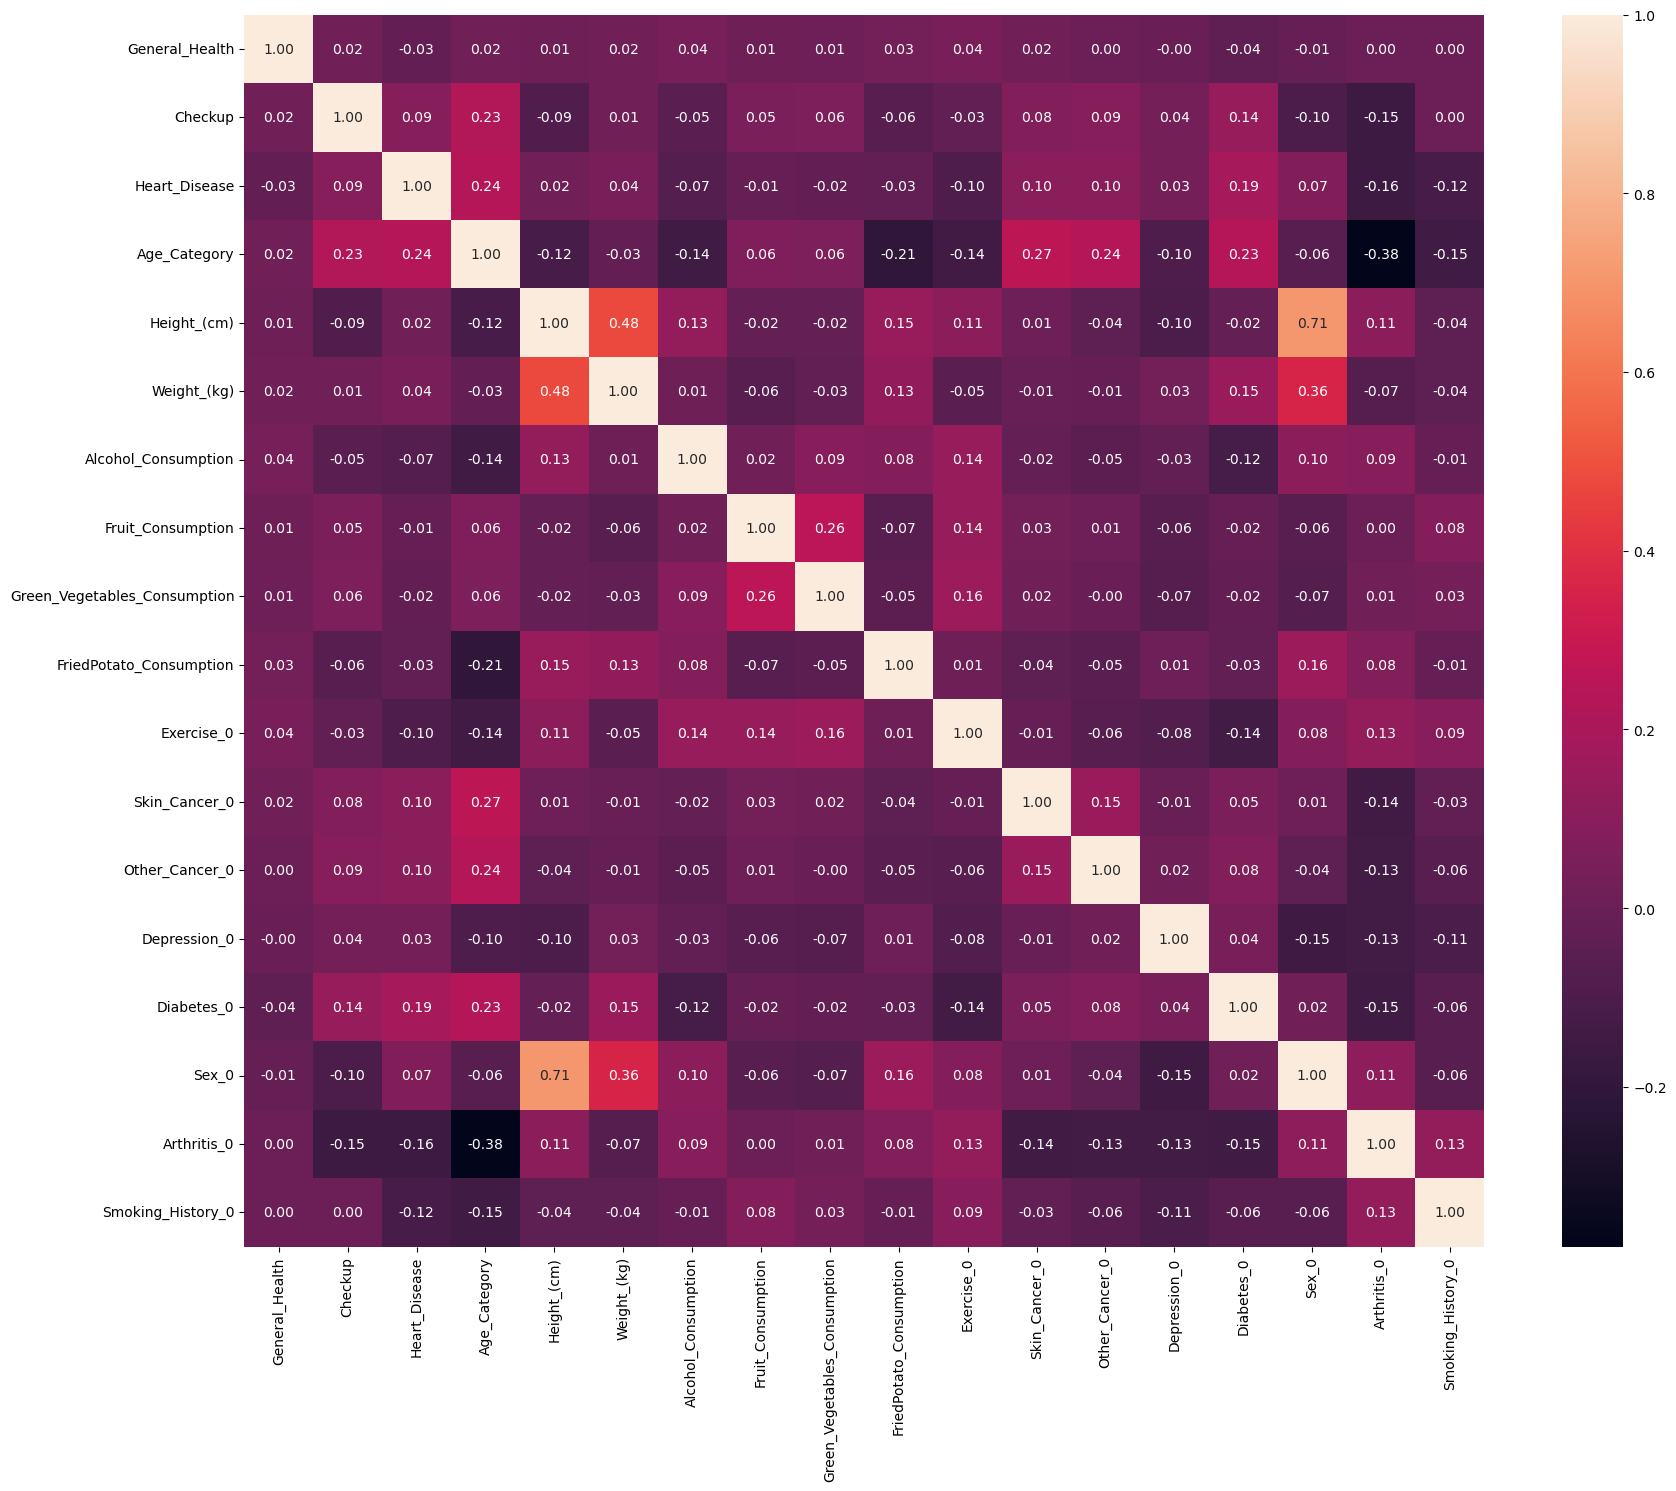

In [129]:
plt.figure(figsize=(20,16))
sns.heatmap(df_encoded.corr(),annot=True,fmt='.2f')

Spliting the the dataset into x and  y as label in y and all the feature in x 

Features

In [130]:
x=df_encoded.drop(['Heart_Disease'],axis=1)

In [131]:
x

,General_Health,Checkup,Age_Category,Height_(cm),Weight_(kg),Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_0,Skin_Cancer_0,Other_Cancer_0,Depression_0,Diabetes_0,Sex_0,Arthritis_0,Smoking_History_0
0,3.0,2.0,10.0,150,32.66,0,30,2.519842,2.289428,0,0,0,0,0,0,0,0
1,4.0,4.0,10.0,165,77.11,0,30,0.000000,1.587401,0,0,0,0,1,0,1,1
2,4.0,4.0,8.0,163,88.45,4,12,1.442250,2.519842,1,0,0,0,1,0,1,1
3,3.0,4.0,11.0,180,93.44,0,30,3.107233,2.000000,1,0,0,0,1,1,1,1
4,2.0,4.0,12.0,191,88.45,0,8,1.587401,0.000000,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,4.0,4.0,1.0,168,81.65,4,30,2.000000,0.000000,1,0,0,0,0,1,1,1
308850,1.0,3.0,9.0,180,69.85,8,15,3.914868,1.587401,1,0,0,0,1,1,1,1
308851,4.0,0.0,2.0,157,61.23,4,40,2.000000,1.587401,1,0,0,1,0,0,1,0
308852,4.0,4.0,9.0,183,79.38,3,30,2.289428,0.000000,1,0,0,0,0,1,1,1


In [132]:
y=df_encoded[['Heart_Disease']]

In [133]:
y

,Heart_Disease
0,0
1,1
2,0
3,1
4,0
...,...
308849,0
308850,0
308851,0
308852,0


Perfoming Standard Scaler on the features

In [134]:
Scaler=StandardScaler()
x_scaled=Scaler.fit_transform(x)
x_scaled

array([[ 0.49132128, -1.48142938,  0.99239803, ..., -0.95778434,
        -1.44174449, -1.20578224],
       [ 1.17368061,  0.47657866,  0.99239803, ..., -0.95778434,
         0.69360418,  0.82933714],
       [ 1.17368061,  0.47657866,  0.43280346, ..., -0.95778434,
         0.69360418,  0.82933714],
       ...,
       [ 1.17368061, -3.43943741, -1.24598024, ..., -0.95778434,
         0.69360418, -1.20578224],
       [ 1.17368061,  0.47657866,  0.71260075, ...,  1.04407637,
         0.69360418,  0.82933714],
       [-1.55575669,  0.47657866, -0.40658839, ..., -0.95778434,
         0.69360418,  0.82933714]])

Checking the Variance inflation factor

In [135]:
vif=pd.DataFrame()
vif['VIF']=[variance_inflation_factor(x_scaled,i) for i in range(x_scaled.shape[1])]
vif['feature']=x.columns


In [136]:
vif

,VIF,feature
0,1.008565,General_Health
1,1.086387,Checkup
2,1.511829,Age_Category
3,2.345942,Height_(cm)
4,1.396046,Weight_(kg)
5,1.071432,Alcohol_Consumption
6,1.102431,Fruit_Consumption
7,1.116542,Green_Vegetables_Consumption
8,1.080892,FriedPotato_Consumption
9,1.117382,Exercise_0


Performing Train Test Split

In [137]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.25,random_state=50)

Applying Logistic Regression

In [138]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


x_train shape: (152380, 17)
x_test shape: (50794, 17)
y_train shape: (152380, 1)
y_test shape: (50794, 1)


In [139]:
logistic=LogisticRegression()

In [140]:
logistic.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

Testing

In [141]:
y_predict=logistic.predict(x_test)

In [142]:
print(len(y_predict),len(y_test))

50794 50794


In [143]:
logistic_test_accuracy=accuracy_score(y_test,y_predict)

In [144]:
logistic_test_accuracy

0.9175099421191479

In [145]:
logistic_test_report=classification_report(y_test,y_predict)

In [146]:
print(logistic_test_report)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     46614
           1       0.48      0.04      0.07      4180

    accuracy                           0.92     50794
   macro avg       0.70      0.52      0.51     50794
weighted avg       0.88      0.92      0.88     50794



Training

In [147]:
y_predict=logistic.predict(x_train)

In [148]:
logistic_train_accuracy=accuracy_score(y_train,y_predict)

In [149]:
logistic_train_accuracy

0.9137878986743667

In [150]:
logistic_test_report=classification_report(y_train,y_predict)

In [151]:
print(logistic_test_report)

              precision    recall  f1-score   support

           0       0.92      1.00      0.95    139320
           1       0.46      0.03      0.06     13060

    accuracy                           0.91    152380
   macro avg       0.69      0.52      0.51    152380
weighted avg       0.88      0.91      0.88    152380



Applying K Neighbors Classifier

In [152]:
Knn=KNeighborsClassifier()

In [153]:
Knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int32](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Testing

In [154]:
y_predicted=Knn.predict(x_test)

  File "C:\Users\Abhay_Thakur_PC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Abhay_Thakur_PC\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Abhay_Thakur_PC\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Abhay_Thakur_PC\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [155]:
print(len(y_predicted),len(y_test))

50794 50794


In [156]:
knn_test_accuracy=accuracy_score(y_test,y_predicted)

In [157]:
knn_test_accuracy

0.9051659644839942

In [158]:
Knn_test_report=classification_report(y_test,y_predicted)

In [159]:
print(Knn_test_report)

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     46614
           1       0.26      0.08      0.13      4180

    accuracy                           0.91     50794
   macro avg       0.59      0.53      0.54     50794
weighted avg       0.87      0.91      0.88     50794



Training

In [160]:
y_predict=Knn.predict(x_train)

In [161]:
train_accuracy=accuracy_score(y_train,y_predict)

In [162]:
train_accuracy

0.9222142013387584

In [163]:
knn_train_report=classification_report(y_train,y_predict)

In [164]:
print(knn_train_report)

              precision    recall  f1-score   support

           0       0.93      0.99      0.96    139320
           1       0.65      0.20      0.31     13060

    accuracy                           0.92    152380
   macro avg       0.79      0.60      0.63    152380
weighted avg       0.91      0.92      0.90    152380



Applying Decision Tree Classifiers

In [165]:
Decision=DecisionTreeClassifier()

In [166]:
Decision.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

Testing

In [167]:
y_predict=Decision.predict(x_test)

In [168]:
dt_test_accuracy=accuracy_score(y_test,y_predict)

In [169]:
dt_test_accuracy

0.8577587904083159

In [170]:
dt_test_report=classification_report(y_test,y_predict)

In [171]:
print(dt_test_report)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     46614
           1       0.20      0.24      0.22      4180

    accuracy                           0.86     50794
   macro avg       0.57      0.58      0.57     50794
weighted avg       0.87      0.86      0.86     50794



Training

In [172]:
y_predict=Decision.predict(x_train)

In [173]:
dt_train_accuracy=accuracy_score(y_train,y_predict)

In [174]:
dt_train_accuracy

0.9999737498359365

In [175]:
dt_train_report=classification_report(y_train,y_predict)

In [176]:
print(dt_train_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    139320
           1       1.00      1.00      1.00     13060

    accuracy                           1.00    152380
   macro avg       1.00      1.00      1.00    152380
weighted avg       1.00      1.00      1.00    152380



Applying RandomForest Classifier

In [177]:
Random_Forest=RandomForestClassifier()

In [178]:
Random_Forest.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Testing

In [179]:
y_predict=Random_Forest.predict(x_test)

In [180]:
rf_test_accuracy=accuracy_score(y_test,y_predict)

In [181]:
rf_test_accuracy

0.9162893255108872

In [182]:
rf_test_report=classification_report(y_test,y_predict)

In [183]:
print(rf_test_report)

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     46614
           1       0.41      0.04      0.07      4180

    accuracy                           0.92     50794
   macro avg       0.67      0.52      0.51     50794
weighted avg       0.88      0.92      0.88     50794



Training

In [184]:
y_predict=Random_Forest.predict(x_train)

In [185]:
rf_train_accuracy=accuracy_score(y_train,y_predict)

In [186]:
rf_train_accuracy

0.9999343745898411

In [187]:
rf_train_report=classification_report(y_train,y_predict)

In [188]:
print(rf_train_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    139320
           1       1.00      1.00      1.00     13060

    accuracy                           1.00    152380
   macro avg       1.00      1.00      1.00    152380
weighted avg       1.00      1.00      1.00    152380



Saving random Forest as it is giving the highest accuracy

In [189]:
import joblib

In [190]:
import os
os.makedirs('models', exist_ok=True)
joblib.dump(Random_Forest, 'models/CVD_predictor.pkl')

['CVD_predictor.pkl']

In [191]:
model = joblib.load('models/CVD_predictor.pkl')